# Estudo longitudinal de Apresentções

Constrói uma base de dados de apresentações artísticas do Siplan para análise longitudinal
(pré-pandemia 2018-19 / retomada 2022-23 / pós-pandemia 2024-25 / atual 2026).

## O que o script faz, célula a célula

| # | O que faz |
|---|---|
| **SQL** | Busca no Hive todas as ações com , aprovadas, não internas. Classifica  via RLIKE em +; agrega  por sessão filtrando . |
| **panorama_ano** | Conta ações e sessões únicas por período e ano. |
| **panorama_ling** | Mesmo recorte, decomposto por linguagem. |
| **precificação** | Extrai  (Pago/Gratuito),  e  do campo  via regex. |
| **período_dia** | Categoriza hora de  em Madrugada / Manhã / Tarde / Noite. |
| **tipo_local** | Classifica em *Na UO*, *Fora da UO* ou *Online*. |
| **local_grupo_apresentacoes** | Classifica o espaço em categorias (Teatros, Auditórios, Palco Externo, Ginásios, Galpão etc.) via lista de regras ordens (REGRAS_LOCAL_GRUPO). Para adicionar novas regras: inserir  na posição correta — específicas antes, gerais depois. |
| **unidades** | Cruza com  para trazer  e . |
| **export** | Salva . |

## Próximos passos planejados
- Análise estatística: evolução de sessões e público por tipo de espaço, UO, linguagem, período do ano e semana — com limpeza de outliers.
- Mesmo pipeline para **Cursos e Oficinas** e **Ações mediadas**.


## Acesso ao HIVE

### Opção A — Kerberos (máquina com DSN configurado)
Execute a célula seguinte (`KERBEROS_CONN_STR`).

### Opção B — Fabric SQL Analytics Endpoint (qualquer máquina)
Execute a célula `FABRIC – acesso alternativo` abaixo **em vez** da célula Kerberos.
Requer na primeira vez: `pip install azure-identity` e ODBC Driver 18 for SQL Server.
Na primeira execução abrirá um link para autenticação no browser (device code).

In [33]:
# FABRIC – acesso alternativo (sem Kerberos)
# Execute ESTA célula em vez da célula Kerberos quando não tiver DSN configurado.
#
# Pré-requisitos:
#   pip install azure-identity
#   ODBC Driver 18 for SQL Server  →  https://learn.microsoft.com/sql/connect/odbc/download-odbc-driver-for-sql-server
#
# Como obter FABRIC_SQL_ENDPOINT:
#   Fabric > workspace "Dados Estatísticos SescSP" > Lakehouse RPS
#   > botão "..." > SQL Analytics Endpoint > copie o "Server"
#   Formato esperado: xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx-xxxxxxxxxxxxxxxxxxxx.datawarehouse.fabric.microsoft.com

import struct
import warnings
import pandas as pd
import pyodbc
from pathlib import Path
from azure.identity import DeviceCodeCredential

OUTPUT_PATH = Path('output')
OUTPUT_PATH.mkdir(exist_ok=True)
DATA_INICIAL = '2017-01-01'

FABRIC_SQL_ENDPOINT = "beu5bmmdbuwedpv62ucm524jzi-wwf452qgaz7e7d2alo7d6ukihe.datawarehouse.fabric.microsoft.com"  # ← edite
DATABASE            = "RPS"
TABELA_FABRIC       = "dbo.EstudoApresentacoes"


def _fabric_token_attr() -> dict:
    credential = DeviceCodeCredential()
    token = credential.get_token("https://database.windows.net/.default")
    token_bytes = token.token.encode("utf-16-le")
    token_struct = struct.pack(f"<I{len(token_bytes)}s", len(token_bytes), token_bytes)
    return {1256: token_struct}   # SQL_COPT_SS_ACCESS_TOKEN


def get_connection() -> pyodbc.Connection:
    conn_str = (
        f"Driver={{ODBC Driver 18 for SQL Server}};"
        f"Server={FABRIC_SQL_ENDPOINT};"
        f"Database={DATABASE};"
        "Encrypt=yes;TrustServerCertificate=no;"
    )
    return pyodbc.connect(conn_str, attrs_before=_fabric_token_attr(), autocommit=True)


def query_to_df(query: str) -> pd.DataFrame:
    with get_connection() as conn:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore',
                message='.*SQLAlchemy connectable.*',
                category=UserWarning,
                module='pandas.io.sql',
            )
            return pd.read_sql_query(query, conn)


# Lê a tabela pré-materializada no Fabric (substitui o SQL Hive da célula original)
df_raw_acoes_preview = query_to_df(f"SELECT * FROM {TABELA_FABRIC}")
print(f"Linhas carregadas do Fabric: {len(df_raw_acoes_preview):,}")

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code ANFE9ZDCC to authenticate.


C:\Users\INTEL\AppData\Local\Temp\ipykernel_16648\2506819197.py:56: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Linhas carregadas do Fabric: 184,342


In [ ]:
import warnings
import numpy as np
import pandas as pd
import pyodbc
from pathlib import Path

OUTPUT_PATH = Path('output')
OUTPUT_PATH.mkdir(exist_ok=True)
DATA_INICIAL = '2017-01-01'

# Ajuste a string abaixo se o DSN exigir parÃ¢metros adicionais.
# Para autenticaÃ§Ã£o Kerberos, normalmente basta usar o DSN configurado.
KERBEROS_CONN_STR = 'DSN=DSN_HIVE_64;Authentication=Kerberos;'
# Se o driver exigir Trusted Connection no Windows, use:
# KERBEROS_CONN_STR = 'DSN=DSN_HIVE_64;Trusted_Connection=Yes;'


def get_connection() -> pyodbc.Connection:
    return pyodbc.connect(KERBEROS_CONN_STR, autocommit=True)


def query_to_df(query: str) -> pd.DataFrame:
    with get_connection() as conn:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore',
                message='.*SQLAlchemy connectable.*',
                category=UserWarning,
                module='pandas.io.sql',
            )
            return pd.read_sql_query(query, conn)


In [ ]:
sql_raw_acoes = f"""
WITH base AS (
    SELECT
        acao.atividade_id,
        acao.uo,
        acao.nome,
        acao.complemento,
        LOWER(CONCAT(COALESCE(acao.desc_modalidade, ''), ' ', COALESCE(acao.desc_subprograma, ''))) AS _txt,
        acao.linguagem          AS categoria,
        acao.desc_subprograma,
        acao.desc_modalidade,
        acao.desc_realizacao,
        acao.formato,
        acao.areaprogramatica_nome,
        acao.precificacao_desc,
        acao.estimativa_publico,
        acao.lugares,
        dt.local_nome,
        dt.grupo_nome           AS local_grupo,
        dt.sessao_id,
        dt.datainicio,
        dt.datafinal,
        SUBSTRING(mens.dia_semana_sessao, 1, 3) AS dia_semana_sessao,
        mens.valor_mensurador   AS presentes
    FROM stg_estatistico.siplan_acao acao
    INNER JOIN stg_estatistico.siplan_data dt
        ON acao.atividade_id = dt.atividade_id
    LEFT JOIN stg_estatistico.siplan_lancamento_mensurador mens
        ON dt.sessao_id = mens.sessao_id
       AND LOWER(mens.lancamento_status) = 'aprovado'
       AND mens.valor_mensurador IS NOT NULL
       AND mens.grupo_nome IN ('Público', 'Presenças')
    WHERE acao.status_atividade = 'APROVADO'
      AND (LOWER(acao.desc_realizacao) LIKE 'apresent%' OR LOWER(acao.desc_realizacao) LIKE 'exibi%')
      AND LOWER(acao.desc_realizacao) NOT LIKE '%esportiva%'
      AND LOWER(acao.desc_subprograma) NOT LIKE '%esportivo%'
      AND acao.uso_interno = 0
      AND acao.manutencao = 0
      AND acao.regular = 0
),
classificado AS (
    SELECT
        atividade_id, uo, nome, complemento,
        CASE
            WHEN _txt LIKE '%circo%'                                                       THEN 'Circo'
            WHEN _txt LIKE '%dança%'       OR _txt LIKE '%danca%'                          THEN 'Dança'
            WHEN _txt LIKE '%música%'      OR _txt LIKE '%musica%'                         THEN 'Música'
            WHEN _txt LIKE '%literatura%'                                                  THEN 'Literatura'
            WHEN _txt LIKE '%audiovisual%' OR _txt LIKE '%cinema%' OR _txt LIKE '%vídeo%'  THEN 'Audiovisual'
            WHEN _txt LIKE '%teatro%'                                                      THEN 'Teatro'
            WHEN categoria IN ('Teatro', 'Dança', 'Circo', 'Música', 'Literatura', 'Audiovisual') THEN categoria
            ELSE NULL
        END AS linguagem,
        desc_subprograma, desc_modalidade, desc_realizacao, formato,
        areaprogramatica_nome, estimativa_publico, lugares, precificacao_desc,
        sessao_id, datainicio, datafinal, local_nome, local_grupo,
        dia_semana_sessao, presentes
    FROM base
)
SELECT
    atividade_id, uo, nome, complemento, linguagem,
    desc_subprograma, desc_modalidade, desc_realizacao, formato,
    areaprogramatica_nome, estimativa_publico, lugares, precificacao_desc,
    sessao_id, datainicio, datafinal, local_nome, local_grupo,
    dia_semana_sessao,
    SUM(presentes) AS presentes
FROM classificado
GROUP BY
    atividade_id, uo, nome, complemento, linguagem,
    desc_subprograma, desc_modalidade, desc_realizacao, formato,
    areaprogramatica_nome, estimativa_publico, lugares, precificacao_desc,
    sessao_id, datainicio, datafinal, local_nome, local_grupo,
    dia_semana_sessao
"""

In [ ]:
# Executa apenas no caminho Kerberos/Hive (quando df_raw_acoes_preview ainda não foi carregado pelo Fabric).
if 'df_raw_acoes_preview' not in dir() or df_raw_acoes_preview is None:
    df_raw_acoes_preview = query_to_df(sql_raw_acoes)
else:
    print(f"df_raw_acoes_preview já carregado ({len(df_raw_acoes_preview):,} linhas) — célula ignorada.")

df_raw_acoes_preview já carregado (184,342 linhas) — célula ignorada.


## Panorama geral

In [65]:
PERIODOS = {
    2017: "Pré-pandemia",
    2018: "Pré-pandemia",
    2019: "Pré-pandemia",
    2022: "Pós-pandemia",
    2023: "Pós-pandemia",
    2024: "Pós-pandemia",
    2025: "RPS",
    2026: "RPS",
}

df = df_raw_acoes_preview.copy()
df["ano"] = pd.to_datetime(df["datainicio"]).dt.year
df = df[df["ano"].isin(PERIODOS)].copy()
df["periodo"] = df["ano"].map(PERIODOS)

# --- Por ano ---
panorama_ano = (
    df.groupby(["periodo", "ano"], sort=False)
    .agg(
        acoes=("atividade_id", "nunique"),
        sessoes=("sessao_id", "nunique"),
    )
    .reset_index()
    .sort_values("ano")
    .reset_index(drop=True)
)
print("Panorama por ano")
# display(panorama_ano)

# --- Por linguagem ---
panorama_ling = (
    df.groupby(["periodo", "ano", "linguagem"], sort=False, dropna=False)
    .agg(
        acoes=("atividade_id", "nunique"),
        sessoes=("sessao_id", "nunique"),
    )
    .reset_index()
    .sort_values(["ano", "linguagem"])
    .reset_index(drop=True)
)
print("Panorama por linguagem")
# display(panorama_ling)

# --- Pivot: acoes por linguagem x ano ---
pivot_acoes = (
    panorama_ling
    .pivot_table(index="linguagem", columns="ano", values="acoes", aggfunc="sum", fill_value=0)
)
pivot_sessoes = (
    panorama_ling
    .pivot_table(index="linguagem", columns="ano", values="sessoes", aggfunc="sum", fill_value=0)
)

pivot_combinado = pd.concat(
    {"Ações": pivot_acoes, "Sessões": pivot_sessoes},
    axis=1,
)
print("Pivot: linguagem x ano (Ações / Sessões)")
display(pivot_combinado)


Panorama por ano
Panorama por linguagem
Pivot: linguagem x ano (Ações / Sessões)


Ações                                         Sessões              \
ano          2017  2018  2019  2022  2023  2024 2025 2026    2017  2018  2019   
linguagem                                                                       
Audiovisual  2471  2456  2425  1404  1554  1726    1    1    4928  4425  4146   
Circo         780   804   786   537   760   829   19    5    1211  1248  1216   
Dança         630   698   763   403   559   523    7    0    1051  1175  1153   
Literatura    990  1165  1097   606   765   779    8    3    1761  2016  2019   
Música       3861  3871  4024  2406  3497  3814   95   17    4846  4917  4936   
Teatro       1464  1555  1543  1092  1249  1285   27    4    3377  3602  3991   

                                         
ano          2022  2023  2024 2025 2026  
linguagem                                
Audiovisual  2504  2978  2401    1    2  
Circo         799  1124  1332   38   16  
Dança         626   888   860   10    0  
Literatura   1071  1443  1460   14    3  
Música       3022  4271  4639  170   26  
Teatro       2851  3248  3235  129   42

## Classifica sessões por período


In [ ]:
# Classifica acesso (pago/gratuito) e extrai valor_min / valor_max de precificacao_desc
import re

_RE_VALOR = re.compile(r'R\$\s*([\d.,]+)')

def _parse_valores(texto):
    """Retorna (valor_min, valor_max) em float a partir dos valores R$ encontrados."""
    if pd.isna(texto):
        return None, None
    matches = [float(v.replace('.', '').replace(',', '.')) for v in _RE_VALOR.findall(str(texto))]
    if not matches:
        return None, None
    return min(matches), max(matches)

def _classifica_acesso(texto):
    if pd.isna(texto):
        return 'Não informado'
    t = str(texto).lower().strip()
    if 'aberto' in t:
        return 'Gratuito'
    return 'Pago'

df_raw_acoes_preview['acesso'] = df_raw_acoes_preview['precificacao_desc'].apply(_classifica_acesso)

_vals = df_raw_acoes_preview['precificacao_desc'].apply(_parse_valores)
df_raw_acoes_preview['valor_min'] = _vals.apply(lambda x: x[0])
df_raw_acoes_preview['valor_max'] = _vals.apply(lambda x: x[1])

# Distribuição de controle
_diag = (
    df_raw_acoes_preview
    .groupby(['precificacao_desc', 'acesso'], dropna=False)
    .agg(
        sessoes   = ('sessao_id', 'nunique'),
        valor_min = ('valor_min', 'min'),
        valor_max = ('valor_max', 'max'),
    )
    .reset_index()
    .sort_values('sessoes', ascending=False)
)
print(f'acesso, valor_min e valor_max adicionados a df_raw_acoes_preview '
      f'({len(df_raw_acoes_preview):,} linhas).')
display(_diag)


In [79]:
def _periodo_dia(dt):
    if pd.isna(dt):
        return None
    h = pd.to_datetime(dt).hour
    if h < 5:    return 'Madrugada'
    if h < 12:   return 'Manhã'
    if h < 18:   return 'Tarde'
    return 'Noite'

df_raw_acoes_preview['periodo_dia'] = df_raw_acoes_preview['datainicio'].apply(_periodo_dia)


## Reclassifica os grupos de locais 

In [67]:
# Cada regra e um dict com chaves opcionais: local, local_ou, grupo, uo, resultado.
# Todas as chaves presentes devem casar (AND). local_ou aceita lista de termos (OR).
# A ordem importa: primeira regra que casar vence.
REGRAS_LOCAL_GRUPO = [
    # --- Casos especificos antes das regras gerais ---
    dict(local='camarim',                             resultado='Outros'),
    dict(local='palco da comedoria',                  resultado='Salas de Espetáculo e Comedorias'),
    dict(local='comedoria',             uo='68',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='comedoria',             uo='63',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='caixa preta',           uo='56',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='térreo',                uo='65',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='restaurante - térreo',  uo='64',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='espaço cênico',         uo='71',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='lanchonete',            uo='71',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='quadra 2',              uo='54',      resultado='Outros'),
    dict(local='ginásio',               uo='54',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='73',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='77',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='93',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='80',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='86',      resultado='Ginásios de eventos'),
    dict(local='ginásio',               uo='84',      resultado='Ginásios de eventos'),
    dict(local='eventos',               uo='83',      resultado='Ginásios de eventos'),
    dict(local='eventos',               uo='82',      resultado='Ginásios de eventos'),
    dict(grupo='espetáculo',            uo='68',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='cênico',                uo='63',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='palco externo',         uo='81',      resultado='Palco Externo'),
    dict(local='teatro [externo]',      uo='92',      resultado='Palco Externo'),
    dict(local='pau brasil',            uo='55',      resultado='Palco Externo'),
    dict(local='tenda',                 uo='72',      resultado='Palco Externo'),
    dict(local='quiosque b',            uo='79',      resultado='Palco Externo'),
    dict(grupo='eventos',               uo='56',      resultado='Palco Externo'),
    dict(grupo='auditório',             uo='89',      resultado='Outros'),
    dict(grupo='auditório',             uo='71',      resultado='Outros'),
    dict(local='teatro [interno]',      uo='92',      resultado='Teatros'),
    dict(local='galpão',                uo='63',      resultado='Salas de Espetáculo e Comedorias'),
    dict(local='solário',               uo='77',      resultado='Praças e Convivências'),
    dict(local='pça coberta',                         resultado='Praças e Convivências'),
    # --- Regras gerais (sem UO) ---
    dict(grupo='cinesesc',                            resultado='Cinesesc'),
    dict(grupo='auditório',                           resultado='Auditórios'),
    dict(local_ou=['convivência', 'praça'],           resultado='Praças e Convivências'),
    dict(grupo='arena',                               resultado='Praças e Convivências'),
    dict(local='arena',                               resultado='Praças e Convivências'),
    dict(grupo='teatro',                              resultado='Teatros'),
    dict(local='arte ii',                             resultado='Salas de Espetáculo e Comedorias'),
    dict(grupo='tenda',                               resultado='Praças e Convivências'),
    dict(grupo='praça de eventos',                    resultado='Praças e Convivências'),
    dict(grupo='múltiplo uso',                        resultado='Múltiplo Uso'),
    dict(grupo='oficina',                             resultado='Múltiplo Uso'),
    dict(grupo='tecnologias',                         resultado='Múltiplo Uso'),
    dict(grupo='quadra poliesportiva',                resultado='Quadras Poliestportivas'),
    dict(grupo='comedoria',                           resultado='Salas de Espetáculo e Comedorias'),
    dict(grupo='galpão',                              resultado='Galpão'),
    dict(local='cpt',                                 resultado='Salas de Espetáculo e Comedorias'),
    dict(grupo='sala de espetáculo',                  resultado='Salas de Espetáculo e Comedorias'),
    dict(local='galpão',                              resultado='Galpão'),
]

def _classifica_local(local, grupo, uo):
    local_l = '' if pd.isna(local) else str(local).lower()
    grupo_l = '' if pd.isna(grupo) else str(grupo).lower()
    uo_l    = '' if pd.isna(uo)    else str(uo).lower()

    for r in REGRAS_LOCAL_GRUPO:
        if 'local'    in r and r['local'].lower()             not in local_l: continue
        if 'local_ou' in r and not any(p.lower() in local_l for p in r['local_ou']): continue
        if 'grupo'    in r and r['grupo'].lower()             not in grupo_l: continue
        if 'uo'       in r and r['uo']                        not in uo_l:    continue
        return r['resultado']

    return 'Outros'


def _tipo_local(local, grupo):
    local_l = '' if pd.isna(local) else str(local).lower()
    grupo_l = '' if pd.isna(grupo) else str(grupo).lower()
    if 'online' in local_l or 'online' in grupo_l:
        return 'Online'
    if 'fora da unidade' in grupo_l:
        return 'Fora da UO'
    return 'Na UO'


df_raw_acoes_preview['tipo_local'] = df_raw_acoes_preview.apply(
    lambda row: _tipo_local(row['local_nome'], row['local_grupo']), axis=1
)
df_raw_acoes_preview['local_grupo_apresentacoes'] = df_raw_acoes_preview.apply(
    lambda row: _classifica_local(row['local_nome'], row['local_grupo'], row['uo']), axis=1
)

In [68]:
panorama_local = (
    df_raw_acoes_preview
    .groupby(['tipo_local', 'local_grupo_apresentacoes'], dropna=False)
    .agg(
        acoes=('atividade_id', 'nunique'),
        sessoes=('sessao_id', 'nunique'),
    )
    .sort_values(['tipo_local', 'sessoes'], ascending=[True, False])
    .reset_index()
)
display(panorama_local)


,tipo_local,local_grupo_apresentacoes,acoes,sessoes
0,Na UO,Teatros,16269,25847
1,Na UO,Praças e Convivências,16485,22426
2,Na UO,Outros,7048,14193
3,Na UO,Salas de Espetáculo e Comedorias,6096,11429
4,Na UO,Cinesesc,3789,7889
5,Na UO,Auditórios,3515,7216
6,Na UO,Múltiplo Uso,2448,4501
7,Na UO,Palco Externo,1884,2233
8,Na UO,Galpão,1003,1179
9,Na UO,Ginásios de eventos,900,994


In [ ]:
# Diagnostico: combinacoes ainda em Outros (mais impactantes primeiro)
# df_outros = (
#     df_raw_acoes_preview[df_raw_acoes_preview['local_grupo_apresentacoes'] == 'Outros']
#     .groupby(['uo', 'local_nome', 'local_grupo'], dropna=False)
#     .agg(
#         acoes=('atividade_id', 'nunique'),
#         sessoes=('sessao_id', 'nunique'),
#     )
#     .sort_values('sessoes', ascending=False)
#     .reset_index()
# )
# with pd.option_context('display.max_rows', None, 'display.max_colwidth', 60):
#     display(df_outros)


In [ ]:
df_unidades = pd.read_csv(
    'unidades.csv',
    dtype={'uo': str},
).rename(columns={'macro-região': 'regiao', 'unidade': 'nome_unidade'})

df_raw_acoes_preview['uo'] = df_raw_acoes_preview['uo'].astype(str)

df_raw_acoes_preview = df_raw_acoes_preview.merge(
    df_unidades,
    on='uo',
    how='left',
)

# # UOs sem correspondencia no CSV
# sem_unidade = df_raw_acoes_preview[df_raw_acoes_preview['nome_unidade'].isna()]['uo'].unique()
# if len(sem_unidade):
#     print(f'UOs sem cadastro em unidades.csv: {sorted(sem_unidade)}')


In [70]:
# ── Overrides de local_grupo_apresentacoes por local + unidade ────────────────
# Executado APÓS o merge com unidades.csv (nome_unidade disponível).
# Adicionar aqui reclassificações pontuais que não cabem nas regras gerais.

_OVERRIDES_GRUPO = [
    # (local_nome_contém,  unidade_contém,   nova_classificação)
    ('ginásio',   'sorocaba',   'Ginásios de eventos'),
    ('ginásio',   'ribeir',     'Ginásios de eventos'),
    ('ginásio',   'bertioga',   'Ginásios de eventos'),
    ('garimpo',   'araraquara', 'Salas de Espetáculo e Comedorias'),
    ('quadra a',  'catanduva',  'Ginásios de eventos'),
]

for _lp, _up, _res in _OVERRIDES_GRUPO:
    _mask = (
        df_raw_acoes_preview['local_nome'].str.lower().str.contains(_lp, na=False) &
        df_raw_acoes_preview['nome_unidade'].str.lower().str.contains(_up, na=False)
    )
    n = _mask.sum()
    if n:
        df_raw_acoes_preview.loc[_mask, 'local_grupo_apresentacoes'] = _res
        print(f"✔ Override → '{_res}': {n} linhas  (local~'{_lp}' | unidade~'{_up}')")
    else:
        print(f"⚠ Nenhuma linha encontrada para local~'{_lp}' | unidade~'{_up}'")

✔ Override → 'Ginásios de eventos': 113 linhas  (local~'ginásio' | unidade~'sorocaba')
✔ Override → 'Ginásios de eventos': 66 linhas  (local~'ginásio' | unidade~'ribeir')
✔ Override → 'Ginásios de eventos': 55 linhas  (local~'ginásio' | unidade~'bertioga')
✔ Override → 'Salas de Espetáculo e Comedorias': 427 linhas  (local~'garimpo' | unidade~'araraquara')
✔ Override → 'Ginásios de eventos': 107 linhas  (local~'quadra a' | unidade~'catanduva')


In [71]:
# Restringe ao escopo presencial na UO antes do diagnóstico de lugares
_total_antes = len(df_raw_acoes_preview)

# Locais mal classificados como Na UO (fora da área da unidade Prudente)
_LOCAIS_EXCLUIR = [
    ("Presidente Epitácio", "Prudente"),
    ("Pirapozinho",         "Prudente"),
]
_mask_excluir = pd.Series(False, index=df_raw_acoes_preview.index)
for _loc, _uo in _LOCAIS_EXCLUIR:
    _mask_excluir |= (
        df_raw_acoes_preview["local_nome"].str.contains(_loc, case=False, na=False) &
        df_raw_acoes_preview["nome_unidade"].str.contains(_uo, case=False, na=False)
    )

df_raw_acoes_preview = df_raw_acoes_preview[
    (df_raw_acoes_preview["tipo_local"] == "Na UO") &
    (pd.to_numeric(df_raw_acoes_preview["presentes"], errors="coerce").fillna(0) > 0) &
    (~_mask_excluir)
].copy()

_removidos = _total_antes - len(df_raw_acoes_preview)
print(
    f"Filtro Na UO: {len(df_raw_acoes_preview):,} linhas mantidas, "
    f"{_removidos:,} removidas (Online + Fora da UO + presentes=0/nulo + locais excluídos)."
)

Filtro Na UO: 98,876 linhas mantidas, 0 removidas (Online + Fora da UO + presentes=0/nulo + locais excluídos).


## Recorrência mensal por local

Para cada espaço (`local_nome` × UO) contamos em quantos meses distintos houve ao menos uma sessão,
dividimos pelo total de meses analisados no dataset e agrupamos em faixas de 10 pp.

O resultado é um histograma de recorrência + uma tabela-catálogo dos locais com ID, classificação e percentual exato.

Meses válidos: 72  (2017-01 → 2024-12, excluindo 2020-2021 e 2026)



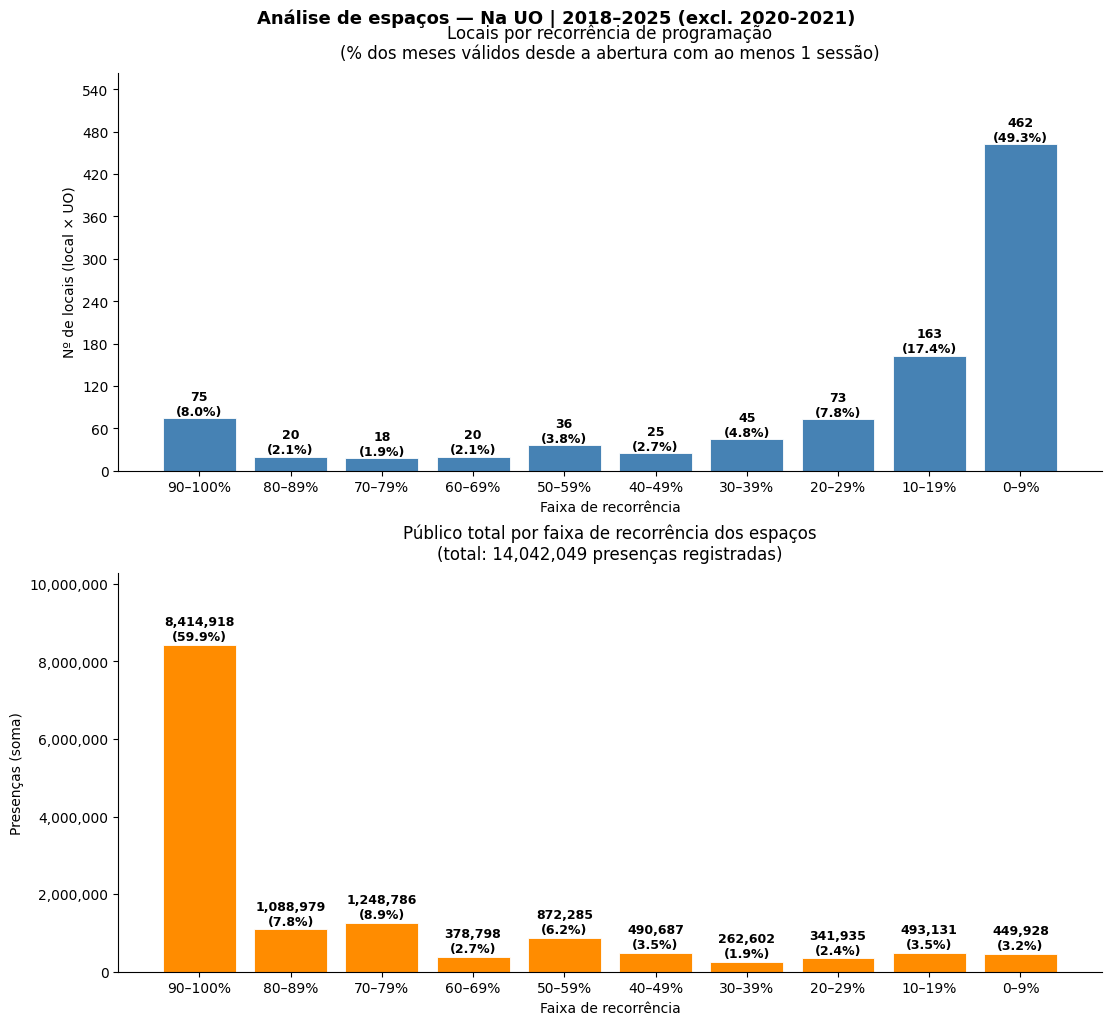


── Resumo por faixa ──


,locais,locais_%,presentes,presentes_%
faixa,,,,
90–100%,75.0,8.0,8414918.0,59.9
80–89%,20.0,2.1,1088979.0,7.8
70–79%,18.0,1.9,1248786.0,8.9
60–69%,20.0,2.1,378798.0,2.7
50–59%,36.0,3.8,872285.0,6.2
40–49%,25.0,2.7,490687.0,3.5
30–39%,45.0,4.8,262602.0,1.9
20–29%,73.0,7.8,341935.0,2.4
10–19%,163.0,17.4,493131.0,3.5



── Catálogo de locais (primeiras 30 linhas) ──


,id,local_uo,local_grupo,unidade,faixa,percentual,meses_com_sessao,meses_possiveis,primeiro_mes
0,049-11,Teatro - 2º andar,Teatros,14 Bis,90–100%,100.0,15,15,2023-10
1,053-12,TEATRO,Teatros,Santana,90–100%,100.0,72,72,2017-01
2,054-01,Biblioteca,Outros,Franca,90–100%,100.0,2,2,2024-11
3,054-02,Comedoria,Salas de Espetáculo e Comedorias,Franca,90–100%,100.0,1,1,2024-12
4,054-03,Convivência,Praças e Convivências,Franca,90–100%,100.0,2,2,2024-11
5,054-04,Diversos Espaços,Outros,Franca,90–100%,100.0,2,2,2024-11
6,054-05,Espaço Juventudes,Outros,Franca,90–100%,100.0,2,2,2024-11
7,054-07,Itinerante,Outros,Franca,90–100%,100.0,2,2,2024-11
8,054-09,Praça,Praças e Convivências,Franca,90–100%,100.0,2,2,2024-11
9,054-10,Sala 4,Múltiplo Uso,Franca,90–100%,100.0,2,2,2024-11


In [72]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Anos válidos: exclui pandemia (2020-2021) e ano corrente parcial (2026) ───
ANOS_VALIDOS = [2017,2018, 2019, 2022, 2023, 2024]

MESES_VALIDOS = pd.PeriodIndex(
    [f"{ano}-{mes:02d}" for ano in ANOS_VALIDOS for mes in range(1, 13)],
    freq='M',
)
print(f"Meses válidos: {len(MESES_VALIDOS)}  "
      f"({MESES_VALIDOS.min()} → {MESES_VALIDOS.max()}, excluindo 2020-2021 e 2026)\n")

# ── Preparo: restringe aos anos válidos ───────────────────────────────────────
_rec = df_raw_acoes_preview.copy()
_rec['datainicio'] = pd.to_datetime(_rec['datainicio'])
_rec['ano_mes'] = _rec['datainicio'].dt.to_period('M')
_rec['ano']     = _rec['datainicio'].dt.year
_rec = _rec[_rec['ano'].isin(ANOS_VALIDOS)].copy()
_rec['presentes'] = pd.to_numeric(_rec['presentes'], errors='coerce')

# ── Meses com sessão + primeiro mês de cada local ────────────────────────────
_local_meses = (
    _rec
    .groupby(['uo', 'local_nome', 'local_grupo_apresentacoes', 'nome_unidade'],
             dropna=False)
    .agg(
        meses_com_sessao=('ano_mes', 'nunique'),
        primeiro_mes    =('ano_mes', 'min'),
    )
    .reset_index()
    .rename(columns={
        'local_grupo_apresentacoes': 'local_grupo',
        'nome_unidade': 'unidade',
    })
)

_local_meses['meses_possiveis'] = _local_meses['primeiro_mes'].apply(
    lambda m: int((MESES_VALIDOS >= m).sum())
)
_local_meses['percentual'] = (
    _local_meses['meses_com_sessao'] / _local_meses['meses_possiveis'] * 100
).round(1).clip(upper=100)

# ── Faixas ────────────────────────────────────────────────────────────────────
FAIXAS_ORDEM = [
    '90–100%', '80–89%', '70–79%', '60–69%', '50–59%',
    '40–49%',  '30–39%', '20–29%', '10–19%', '0–9%',
]

def _faixa(pct):
    for limiar, label in [(90, '90–100%'), (80, '80–89%'), (70, '70–79%'),
                           (60, '60–69%'), (50, '50–59%'), (40, '40–49%'),
                           (30, '30–39%'), (20, '20–29%'), (10, '10–19%')]:
        if pct >= limiar:
            return label
    return '0–9%'

_local_meses['faixa'] = _local_meses['percentual'].apply(_faixa)

# ── ID ────────────────────────────────────────────────────────────────────────
_local_meses = _local_meses.sort_values(['uo', 'local_nome']).reset_index(drop=True)
_local_meses['_seq'] = _local_meses.groupby('uo').cumcount() + 1
_local_meses['id']   = _local_meses.apply(
    lambda r: f"{int(r['uo']):03d}-{r['_seq']:02d}"
    if str(r['uo']).isdigit() else f"{r['uo']}-{r['_seq']:02d}",
    axis=1
)

# ── Tabela-catálogo ───────────────────────────────────────────────────────────
df_locais_recorrencia = (
    _local_meses
    [['id', 'local_nome', 'local_grupo', 'unidade',
      'faixa', 'percentual', 'meses_com_sessao', 'meses_possiveis', 'primeiro_mes']]
    .rename(columns={'local_nome': 'local_uo'})
    .sort_values(['faixa', 'percentual', 'id'],
                 key=lambda s: s.map(FAIXAS_ORDEM.index) if s.name == 'faixa' else s,
                 ascending=[True, False, True])
    .reset_index(drop=True)
)

# ── Presentes por faixa ───────────────────────────────────────────────────────
_presentes_faixa = (
    _rec
    .merge(_local_meses[['uo', 'local_nome', 'faixa']], on=['uo', 'local_nome'], how='left')
    .groupby('faixa', dropna=False)['presentes']
    .sum()
    .reindex(FAIXAS_ORDEM, fill_value=0)
)

# ── Contagem de locais por faixa ──────────────────────────────────────────────
contagem_faixas = (
    _local_meses['faixa']
    .value_counts()
    .reindex(FAIXAS_ORDEM, fill_value=0)
)

TOTAL_LOCAIS    = contagem_faixas.sum()
TOTAL_PRESENTES = _presentes_faixa.sum()

# ── Dois histogramas ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), constrained_layout=True)

# — Gráfico 1: locais —
bars1 = ax1.bar(contagem_faixas.index, contagem_faixas.values,
                color='steelblue', edgecolor='white', linewidth=0.6)
for bar, n in zip(bars1, contagem_faixas.values):
    if n:
        pct = n / TOTAL_LOCAIS * 100
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{n}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Locais por recorrência de programação\n'
              '(% dos meses válidos desde a abertura com ao menos 1 sessão)',
              fontsize=12, pad=10)
ax1.set_xlabel('Faixa de recorrência', fontsize=10)
ax1.set_ylabel('Nº de locais (local × UO)', fontsize=10)
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_ylim(0, contagem_faixas.max() * 1.22)
ax1.spines[['top', 'right']].set_visible(False)

# — Gráfico 2: presentes —
bars2 = ax2.bar(_presentes_faixa.index, _presentes_faixa.values,
                color='darkorange', edgecolor='white', linewidth=0.6)
for bar, v in zip(bars2, _presentes_faixa.values):
    if v:
        pct = v / TOTAL_PRESENTES * 100
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + TOTAL_PRESENTES * 0.003,
                 f"{v:,.0f}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_title('Público total por faixa de recorrência dos espaços\n'
              f'(total: {TOTAL_PRESENTES:,.0f} presenças registradas)',
              fontsize=12, pad=10)
ax2.set_xlabel('Faixa de recorrência', fontsize=10)
ax2.set_ylabel('Presenças (soma)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_ylim(0, _presentes_faixa.max() * 1.22)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Análise de espaços — Na UO | 2018–2025 (excl. 2020-2021)',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

# ── Resumo tabular ────────────────────────────────────────────────────────────
_resumo = pd.DataFrame({
    'locais':        contagem_faixas,
    'locais_%':      (contagem_faixas / TOTAL_LOCAIS * 100).round(1),
    'presentes':     _presentes_faixa.astype(int),
    'presentes_%':   (_presentes_faixa / TOTAL_PRESENTES * 100).round(1),
})
_resumo.loc['TOTAL'] = [
    TOTAL_LOCAIS, 100.0,
    int(TOTAL_PRESENTES), 100.0,
]
print("\n── Resumo por faixa ──")
display(_resumo)

print("\n── Catálogo de locais (primeiras 30 linhas) ──")
display(df_locais_recorrencia.head(30))

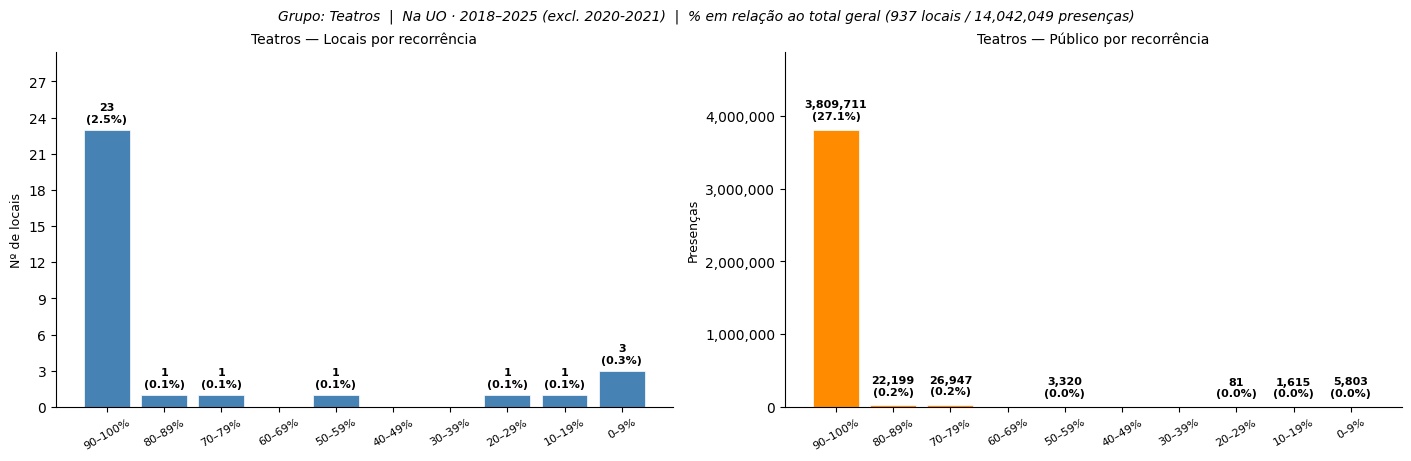

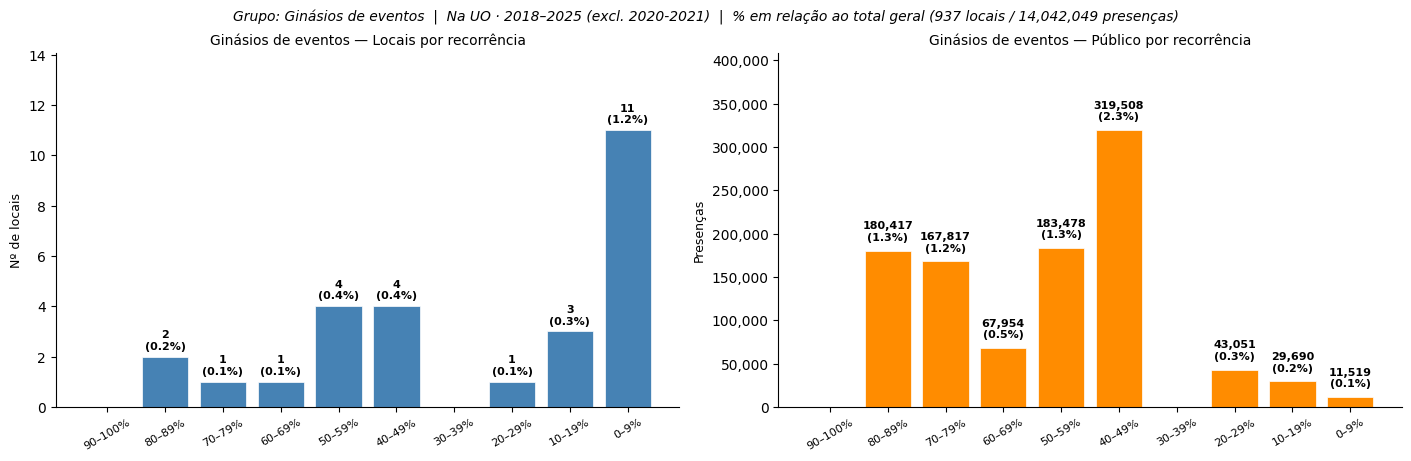

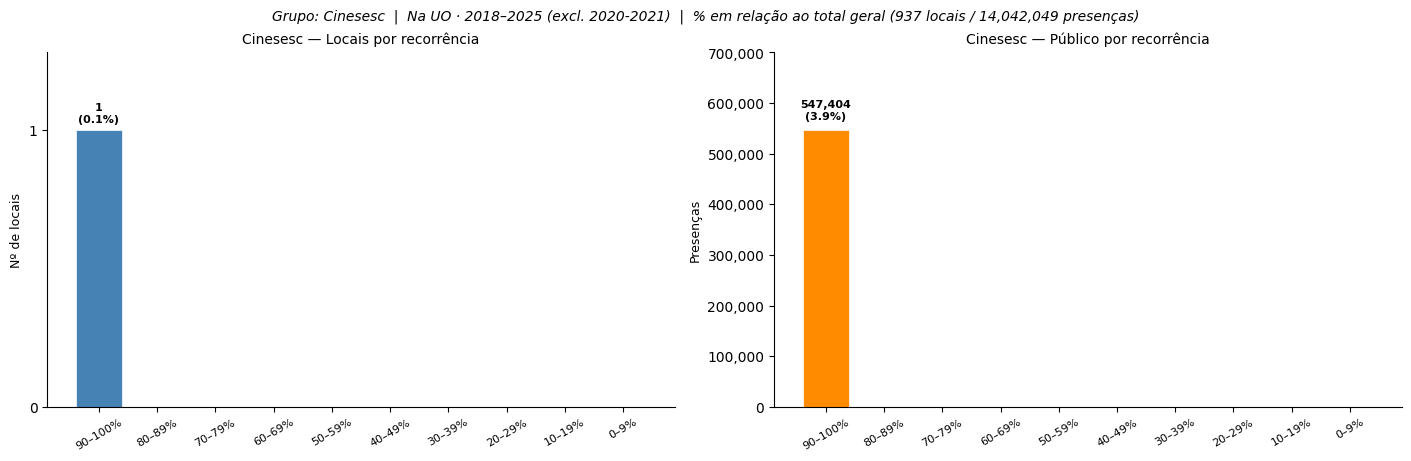

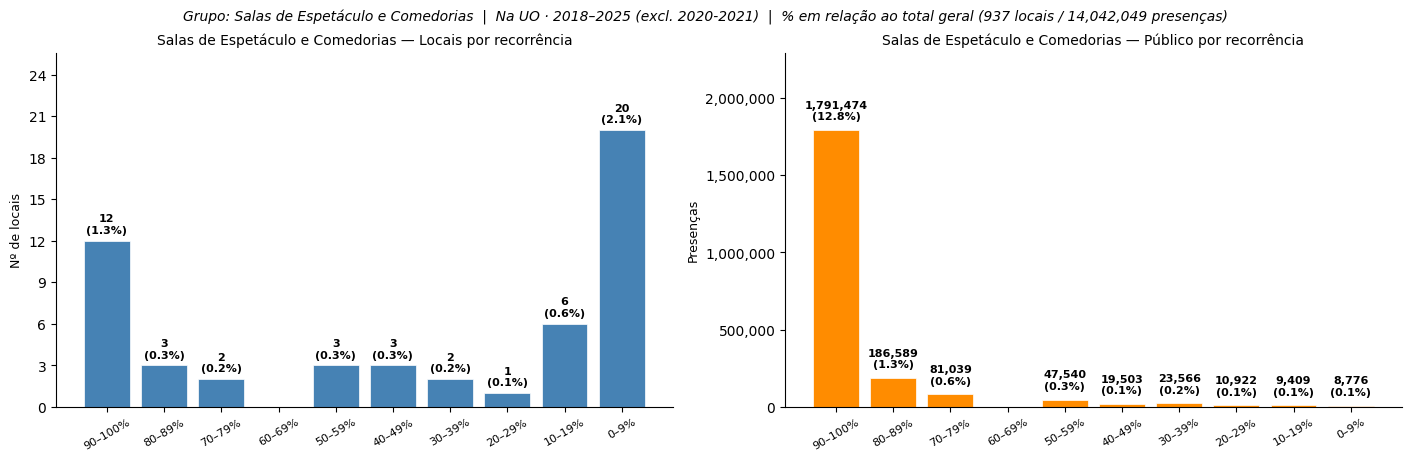

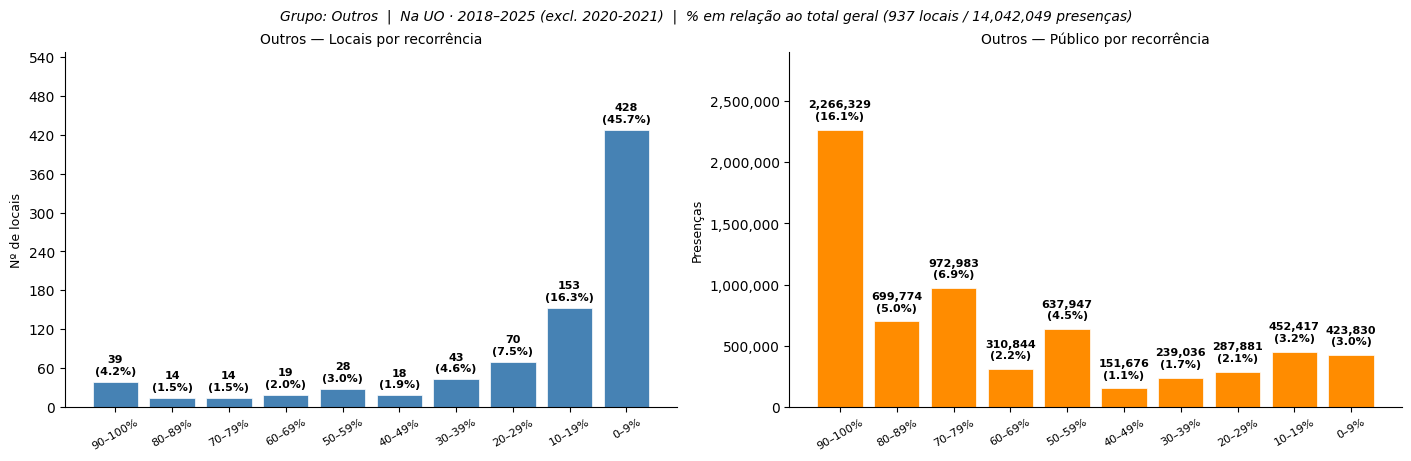

── Resumo por grupo × faixa ──


,grupo_grafico,faixa,locais,presentes,locais_%,presentes_%
0,Cinesesc,90–100%,1,547404.0,0.1,3.9
1,Ginásios de eventos,80–89%,2,180417.0,0.2,1.3
2,Ginásios de eventos,70–79%,1,167817.0,0.1,1.2
3,Ginásios de eventos,60–69%,1,67954.0,0.1,0.5
4,Ginásios de eventos,50–59%,4,183478.0,0.4,1.3
5,Ginásios de eventos,40–49%,4,319508.0,0.4,2.3
6,Ginásios de eventos,20–29%,1,43051.0,0.1,0.3
7,Ginásios de eventos,10–19%,3,29690.0,0.3,0.2
8,Ginásios de eventos,0–9%,11,11519.0,1.2,0.1
9,Outros,90–100%,39,2266329.0,4.2,16.1


In [73]:
# ── Histogramas por grupo de espaço ──────────────────────────────────────────
# % sempre em relação ao total geral (TOTAL_LOCAIS / TOTAL_PRESENTES da célula anterior)

GRUPOS_GRAFICOS = [
    'Teatros',
    'Ginásios de eventos',
    'Cinesesc',
    'Salas de Espetáculo e Comedorias',
    'Outros',
]

# Classifica cada local no grupo para este recorte (5 categorias)
def _grupo_grafico(g):
    if g in {'Teatros', 'Ginásios de eventos', 'Cinesesc', 'Salas de Espetáculo e Comedorias'}:
        return g
    return 'Outros'

_local_meses['grupo_grafico'] = _local_meses['local_grupo'].apply(_grupo_grafico)

# Junta grupo_grafico ao _rec para calcular presentes por grupo × faixa
_rec_com_faixa = _rec.merge(
    _local_meses[['uo', 'local_nome', 'faixa', 'grupo_grafico']],
    on=['uo', 'local_nome'],
    how='left',
)

def _plot_grupo(grupo, ax1, ax2):
    _lm = _local_meses[_local_meses['grupo_grafico'] == grupo]
    _pf = (
        _rec_com_faixa[_rec_com_faixa['grupo_grafico'] == grupo]
        .groupby('faixa', dropna=False)['presentes']
        .sum()
        .reindex(FAIXAS_ORDEM, fill_value=0)
    )
    cnt = _lm['faixa'].value_counts().reindex(FAIXAS_ORDEM, fill_value=0)

    # — locais —
    bars1 = ax1.bar(cnt.index, cnt.values, color='steelblue', edgecolor='white', linewidth=0.5)
    for bar, n in zip(bars1, cnt.values):
        if n:
            pct_loc = n / TOTAL_LOCAIS * 100
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + cnt.max() * 0.02,
                     f"{n}\n({pct_loc:.1f}%)",
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax1.set_title(f'{grupo} — Locais por recorrência', fontsize=10, pad=6)
    ax1.set_ylabel('Nº de locais', fontsize=9)
    ax1.set_ylim(0, max(cnt.max(), 1) * 1.28)
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.tick_params(axis='x', labelsize=8, rotation=30)
    ax1.spines[['top', 'right']].set_visible(False)

    # — presentes —
    bars2 = ax2.bar(_pf.index, _pf.values, color='darkorange', edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars2, _pf.values):
        if v:
            pct_pub = v / TOTAL_PRESENTES * 100
            ax2.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(_pf.max(), 1) * 0.03,
                     f"{v:,.0f}\n({pct_pub:.1f}%)",
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax2.set_title(f'{grupo} — Público por recorrência', fontsize=10, pad=6)
    ax2.set_ylabel('Presenças', fontsize=9)
    ax2.set_ylim(0, max(_pf.max(), 1) * 1.28)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.tick_params(axis='x', labelsize=8, rotation=30)
    ax2.spines[['top', 'right']].set_visible(False)

# Um par de gráficos por grupo
for grupo in GRUPOS_GRAFICOS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    _plot_grupo(grupo, ax1, ax2)
    fig.suptitle(
        f'Grupo: {grupo}  |  Na UO · 2018–2025 (excl. 2020-2021)  '
        f'|  % em relação ao total geral ({TOTAL_LOCAIS} locais / {TOTAL_PRESENTES:,.0f} presenças)',
        fontsize=10, style='italic',
    )
    plt.show()

# ── Tabela resumo por grupo × faixa ──────────────────────────────────────────
_resumo_grupo = (
    _local_meses
    .groupby(['grupo_grafico', 'faixa'])
    .agg(locais=('id', 'count'))
    .reset_index()
    .merge(
        _rec_com_faixa.groupby(['grupo_grafico', 'faixa'])['presentes'].sum().reset_index(),
        on=['grupo_grafico', 'faixa'], how='left',
    )
)
_resumo_grupo['locais_%']    = (_resumo_grupo['locais']    / TOTAL_LOCAIS    * 100).round(1)
_resumo_grupo['presentes_%'] = (_resumo_grupo['presentes'] / TOTAL_PRESENTES * 100).round(1)
_resumo_grupo['faixa'] = pd.Categorical(_resumo_grupo['faixa'], categories=FAIXAS_ORDEM, ordered=True)
_resumo_grupo = _resumo_grupo.sort_values(['grupo_grafico', 'faixa']).reset_index(drop=True)

print("── Resumo por grupo × faixa ──")
display(_resumo_grupo)

In [74]:
# ── Seleção refinada de espaços ───────────────────────────────────────────────
# CRITÉRIO FINAL:
#   1. Critérios por grupo (→ ~87 espaços)
#   2. Complemento por público até exatamente 100 (excl. Osasco, descontinuidade)

def _grupo_grafico(g):
    if g in {'Teatros', 'Ginásios de eventos', 'Cinesesc', 'Salas de Espetáculo e Comedorias'}:
        return g
    return 'Outros'

_local_meses['grupo_grafico'] = _local_meses['local_grupo'].apply(_grupo_grafico)
_local_meses['selecao'] = None

# 1. Cinesesc — todos
_local_meses.loc[_local_meses['grupo_grafico'] == 'Cinesesc', 'selecao'] = 'recorrente'

# 2. Teatros — top-26 acima de 70 %
_idx = (
    _local_meses[(_local_meses['grupo_grafico'] == 'Teatros') & (_local_meses['percentual'] > 70)]
    .nlargest(26, 'percentual').index
)
_local_meses.loc[_idx, 'selecao'] = 'recorrente'

# 3. Ginásios — top-10 acima de 40 %
_idx = (
    _local_meses[(_local_meses['grupo_grafico'] == 'Ginásios de eventos') & (_local_meses['percentual'] > 40)]
    .nlargest(10, 'percentual').index
)
_local_meses.loc[_idx, 'selecao'] = 'recorrente'

# 4. Salas de Espetáculo — top-10 acima de 90 %
_idx = (
    _local_meses[(_local_meses['grupo_grafico'] == 'Salas de Espetáculo e Comedorias') & (_local_meses['percentual'] > 90)]
    .nlargest(10, 'percentual').index
)
_local_meses.loc[_idx, 'selecao'] = 'recorrente'

# 5. Outros — > 80 %: recorrente  |  50–80 %: em análise
_EXCLUIR_OUTROS = {'Múltiplo Uso', 'Outros', 'Quadras Poliestportivas'}
_outros = (
    (_local_meses['grupo_grafico'] == 'Outros') &
    (~_local_meses['local_grupo'].isin(_EXCLUIR_OUTROS))
)
_local_meses.loc[_outros & (_local_meses['percentual'] >  80), 'selecao'] = 'recorrente'
_local_meses.loc[_outros & (_local_meses['percentual'] >  50) & (_local_meses['percentual'] <= 80), 'selecao'] = 'em análise'

# ── Complemento por público até 100 (excl. Osasco por descontinuidade) ────────
# IMPORTANTE: usa .join() para preservar o índice original de _local_meses
_n_rec_base = (_local_meses['selecao'] == 'recorrente').sum()
_n_faltam = 100 - _n_rec_base
print(f"Critérios por grupo → {_n_rec_base} recorrentes  |  complemento necessário: {_n_faltam}")

if _n_faltam > 0:
    _presentes_comp = (
        _rec.groupby(['uo', 'local_nome'])['presentes']
        .sum()
        .rename('presentes_total')
    )
    # .join() preserva o índice do lado esquerdo — essencial para o .loc[] abaixo
    _lm_pool = _local_meses[
        (_local_meses['selecao'].isna()) &
        (~_local_meses['unidade'].str.contains('Osasco', case=False, na=False))
    ].copy()
    _lm_pool = _lm_pool.join(
        _presentes_comp,
        on=['uo', 'local_nome']
    ).fillna({'presentes_total': 0})
    _complemento = _lm_pool.sort_values('presentes_total', ascending=False).head(_n_faltam)
    _local_meses.loc[_complemento.index, 'selecao'] = 'recorrente'

    print(f"\n  Espaços adicionados ao complemento (top {_n_faltam} por público):")
    for _, r in _complemento.iterrows():
        print(f"    {str(r['unidade']):<30} {r['local_nome']:<30} {r['local_grupo']:<28}  {r['presentes_total']:>10,.0f}")

# ── Correções de grupo_grafico para exibição dos 100 recorrentes ──────────────
_CORR_GRUPO_DISPLAY = [
    # (local_nome_contém, unidade_contém, grupo_grafico_corrigido)
    ('palco da orquestra', '',          'Outros'),
    ('ginásio',            'sorocaba',  'Ginásios de eventos'),
    ('multiuso',           'campinas',  'Outros'),
]
for _lp, _up, _grp in _CORR_GRUPO_DISPLAY:
    _mask = (
        (_local_meses['selecao'] == 'recorrente') &
        (_local_meses['local_nome'].str.lower().str.contains(_lp, na=False))
    )
    if _up:
        _mask &= _local_meses['unidade'].str.lower().str.contains(_up, na=False)
    if _mask.any():
        _local_meses.loc[_mask, 'grupo_grafico'] = _grp
        print(f"\n✔ grupo_grafico corrigido → '{_grp}': {_mask.sum()} espaço(s)  (local~'{_lp}')")

# Propaga para df_locais_recorrencia
_id_to_sel = dict(zip(_local_meses['id'], _local_meses['selecao']))
df_locais_recorrencia['selecao'] = df_locais_recorrencia['id'].map(_id_to_sel)

# ── Diagnóstico final ─────────────────────────────────────────────────────────
_n_final = (_local_meses['selecao'] == 'recorrente').sum()
print(f"\nResultado da seleção:")
for k, v in _local_meses['selecao'].value_counts(dropna=False).items():
    print(f"  {str(k):<15} {v:>4} locais")
print(f"\nTotal recorrentes: {_n_final}  |  TOTAL_PRESENTES = {TOTAL_PRESENTES:,.0f}")

# ── Filtro da base principal (apenas recorrentes) ─────────────────────────────
_locais_rec = _local_meses[_local_meses['selecao'] == 'recorrente'][['uo', 'local_nome']]
df_apresentacoes = df_raw_acoes_preview.merge(_locais_rec, on=['uo', 'local_nome'], how='inner')
print(f"\nBase filtrada (recorrentes): {len(df_apresentacoes):,} linhas  "
      f"| {df_apresentacoes['sessao_id'].nunique():,} sessões")

# ── Listagem por categoria e unidade ─────────────────────────────────────────
print("\n" + "═" * 78)
print("  100 ESPAÇOS RECORRENTES — por categoria e unidade")
print("═" * 78)

for grupo in ['Teatros', 'Ginásios de eventos', 'Cinesesc',
              'Salas de Espetáculo e Comedorias', 'Outros']:
    _grupo_df = (
        _local_meses[
            (_local_meses['grupo_grafico'] == grupo) &
            (_local_meses['selecao'] == 'recorrente')
        ]
        .sort_values(['unidade', 'percentual'], ascending=[True, False])
        .reset_index(drop=True)
    )
    if _grupo_df.empty:
        continue

    print(f"\n▌ {grupo}  ({len(_grupo_df)} espaços)")
    print(f"  {'Unidade':<38} {'Local':<36} {'%':>6}")
    print(f"  {'-'*38} {'-'*36} {'-'*6}")

    _ult_unidade = None
    for _, row in _grupo_df.iterrows():
        unidade_label = row['unidade'] if row['unidade'] != _ult_unidade else ''
        _ult_unidade  = row['unidade']
        print(f"  {unidade_label:<38} {row['local_nome']:<36} {row['percentual']:>5.1f}%")


Critérios por grupo → 85 recorrentes  |  complemento necessário: 15

  Espaços adicionados ao complemento (top 15 por público):
    Carmo                          Restaurante - Térreo           Salas de Espetáculo e Comedorias     134,310
    Av. Paulista                   Térreo                         Salas de Espetáculo e Comedorias     133,828
    Pompeia                        Deck Solariun                  Outros                            74,767
    São Carlos                     Ginásio de eventos (inteiro)   Ginásios de eventos               74,667
    Campinas                       Espaço Multiuso                Múltiplo Uso                      72,017
    Sorocaba                       Ginásio                        Ginásios de eventos               70,635
    Interlagos                     ARENA PRAIA                    Praças e Convivências             62,868
    Santos                         Cafeteria - Café do Teatro     Salas de Espetáculo e Comedorias      53,724
    

## Nota metodológica — Seleção dos 100 espaços de apresentação recorrentes

A análise longitudinal cobre **seis anos de programação artística nas unidades do Sesc SP**:
pré-pandemia (2018–2019), retomada (2022–2023) e pós-pandemia (2024–2025) — totalizando
**72 meses válidos**. Os anos de 2020 e 2021 foram excluídos por descontinuidade operacional,
e 2026 por ser ano corrente parcial. O universo de referência são todas as ações do tipo
*apresentação* ou *exibição* realizadas **nas dependências das unidades** (*Na UO*),
excluídas ações de uso interno, manutenção, esportivas e ações regulares.

### Etapa 1 — Recorrência por categoria

Para cada espaço físico (combinação de unidade × nome do local), calculou-se o
**percentual de meses com ao menos uma sessão** em relação aos meses válidos desde
a primeira ação registrada naquele espaço. A partir desse indicador, foram definidos
critérios de seleção diferenciados por categoria:

| Categoria | Critério |
|---|---|
| **Cinesesc** | Todos os espaços (programação sistemática por natureza) |
| **Teatros** | Os 26 espaços com recorrência > 70 % |
| **Ginásios de eventos** | Os 10 espaços com recorrência > 40 % |
| **Salas de Espetáculo e Comedorias** | Os 10 espaços com recorrência > 90 % |
| **Demais categorias** *(Praças, Palcos, Auditórios etc.)* | Espaços com recorrência > 80 % |

Esse conjunto inicial resultou em **~87 espaços**, representando os locais com programação
mais estável e contínua em cada tipo de espaço.

### Etapa 2 — Complemento por público

Para atingir exatamente **100 espaços**, os 13 complementares foram selecionados
entre todos os espaços ainda não classificados — exceto os da unidade Osasco,
cujas ações foram descontinuadas no período —, priorizando aqueles com o
**maior público acumulado** nos anos válidos. O critério de público garante que
cada espaço adicionado maximize a cobertura de audiência.

### Resultado

Os **100 espaços recorrentes** representam uma fração do total de locais com
ao menos uma ação de apresentação registrada no período, mas concentram a
parcela mais expressiva do público — conforme detalhado na tabela abaixo.
A análise longitudinal nas seções seguintes restringe-se a esse conjunto.


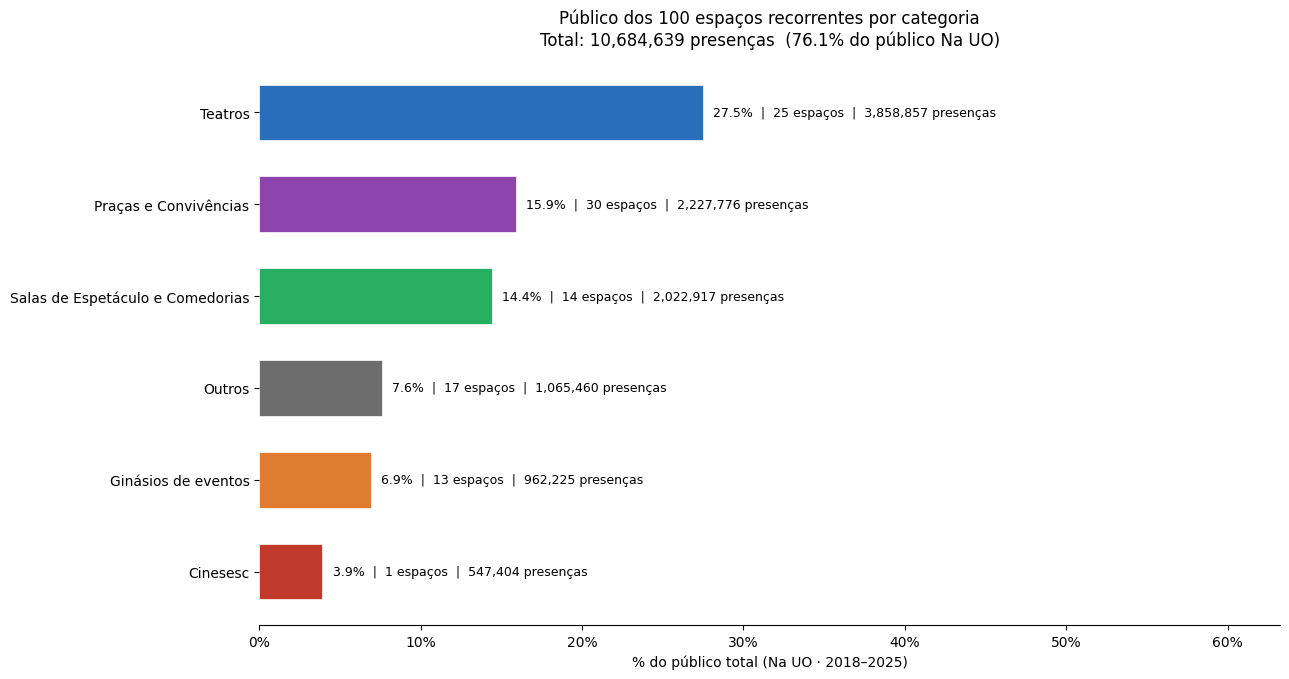

,Grupo de espaço,Espaços,Presenças,% público Na UO
0,Teatros,25,"3,858,857",27.5%
1,Praças e Convivências,30,"2,227,776",15.9%
2,Salas de Espetáculo e Comedorias,14,"2,022,917",14.4%
3,Outros,17,"1,065,460",7.6%
4,Ginásios de eventos,13,"962,225",6.9%
5,Cinesesc,1,"547,404",3.9%
6,TOTAL recorrentes,100,"10,684,639",76.1%


In [75]:
# ── Público dos 100 espaços recorrentes por categoria de exibição ─────────────
# Categorias de exibição (diferente de grupo_grafico usado na seleção):
#   Teatros, Praças e Convivências, Salas de Espetáculo e Comedorias,
#   Ginásios de eventos, Cinesesc  →  exibidos individualmente
#   Tudo mais (Palco Externo, Auditórios, Outros, Galpão…) → agrupado em 'Outros'

_CATS_PROPRIAS = {
    'Teatros', 'Ginásios de eventos', 'Cinesesc',
    'Salas de Espetáculo e Comedorias', 'Praças e Convivências',
}

def _cat_display(local_grupo):
    return local_grupo if local_grupo in _CATS_PROPRIAS else 'Outros'

_lm_rec = _local_meses[_local_meses['selecao'] == 'recorrente'].copy()
_lm_rec['cat_display'] = _lm_rec['local_grupo'].apply(_cat_display)

# Contagem de espaços por categoria
_espacos_cat = _lm_rec.groupby('cat_display').size().rename('espacos')

# Presentes: junta cat_display ao _rec e filtra recorrentes
_rec_cat = _rec.merge(
    _lm_rec[['uo', 'local_nome', 'cat_display']],
    on=['uo', 'local_nome'], how='inner'
)
_presentes_cat = _rec_cat.groupby('cat_display')['presentes'].sum().rename('presentes')

_resumo_cat = (
    pd.concat([_espacos_cat, _presentes_cat], axis=1)
    .fillna(0)
    .astype({'espacos': int, 'presentes': float})
    .reset_index()
    .rename(columns={'cat_display': 'categoria'})
)
_resumo_cat['pct_publico'] = (_resumo_cat['presentes'] / TOTAL_PRESENTES * 100).round(1)
_resumo_cat = _resumo_cat.sort_values('presentes', ascending=False).reset_index(drop=True)

_total_esp = _resumo_cat['espacos'].sum()
_total_pub = _resumo_cat['presentes'].sum()
_total_pct = _total_pub / TOTAL_PRESENTES * 100

# ── Paleta ────────────────────────────────────────────────────────────────────
CORES_CATS = {
    'Teatros':                          '#2a6ebb',
    'Praças e Convivências':            '#8e44ad',
    'Salas de Espetáculo e Comedorias': '#27ae60',
    'Ginásios de eventos':              '#e07b30',
    'Cinesesc':                         '#c0392b',
    'Outros':                           '#6d6d6d',
}

# ── Gráfico horizontal ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, max(4, len(_resumo_cat) * 0.9 + 1.5)))

bars = ax.barh(
    _resumo_cat['categoria'],
    _resumo_cat['pct_publico'],
    color=[CORES_CATS.get(g, '#aaaaaa') for g in _resumo_cat['categoria']],
    edgecolor='white', linewidth=0.5,
    height=0.6,
)

for bar, row in zip(bars, _resumo_cat.itertuples()):
    label = (
        f"  {row.pct_publico:.1f}%  |  "
        f"{row.espacos} espaços  |  "
        f"{row.presentes:,.0f} presenças"
    )
    ax.text(bar.get_width() + 0.15,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', ha='left', fontsize=9)

ax.set_xlabel('% do público total (Na UO · 2018–2025)', fontsize=10)
ax.set_xlim(0, _resumo_cat['pct_publico'].max() * 2.3)
ax.set_title(
    f'Público dos {_total_esp} espaços recorrentes por categoria\n'
    f'Total: {_total_pub:,.0f} presenças  ({_total_pct:.1f}% do público Na UO)',
    fontsize=12, pad=10,
)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

# ── Tabela de apoio ───────────────────────────────────────────────────────────
_tab = _resumo_cat.copy()
_tab.loc[len(_tab)] = {
    'categoria':   'TOTAL recorrentes',
    'espacos':     _total_esp,
    'presentes':   _total_pub,
    'pct_publico': round(_total_pct, 1),
}
_tab['presentes']   = _tab['presentes'].apply(lambda x: f'{x:,.0f}')
_tab['pct_publico'] = _tab['pct_publico'].apply(lambda x: f'{x:.1f}%')
_tab.columns = ['Grupo de espaço', 'Espaços', 'Presenças', '% público Na UO']
display(_tab.reset_index(drop=True))


In [76]:
# ── Diagnóstico: presentes por ano na base bruta ─────────────────────────────
# Verifica se o problema é na carga dos dados (mensurador não aprovado em 2025)

_base = df_raw_acoes_preview.copy()
_base["presentes"] = pd.to_numeric(_base["presentes"], errors="coerce")
_base["_ano"] = pd.to_datetime(_base["datainicio"], errors="coerce").dt.year

_diag_anos = (
    _base[_base["_ano"].between(2017, 2024)]
    .groupby("_ano")
    .agg(
        sessoes_total   = ("sessao_id",  "nunique"),
        com_presentes   = ("sessao_id",  lambda x: _base.loc[x.index, "presentes"].notna().sum()),
        presentes_total = ("presentes",  "sum"),
    )
    .reset_index()
)
_diag_anos["sem_presentes"] = _diag_anos["sessoes_total"] - _diag_anos["com_presentes"]
_diag_anos["pct_com"] = (_diag_anos["com_presentes"] / _diag_anos["sessoes_total"] * 100).round(1)
print("Distribuição de presenças por ano — base bruta (df_raw_acoes_preview):")
display(_diag_anos[["_ano","sessoes_total","com_presentes","sem_presentes","pct_com","presentes_total"]])

# Cinesesc especificamente
print("Cinesesc — sessoes e presentes por ano:")
_cin = _base[_base["local_grupo_apresentacoes"] == "Cinesesc"].copy()
_cin_diag = (
    _cin[_cin["_ano"].between(2017, 2024)]
    .groupby("_ano")
    .agg(
        sessoes_total   = ("sessao_id",  "nunique"),
        com_presentes   = ("sessao_id",  lambda x: _cin.loc[x.index, "presentes"].notna().sum()),
        presentes_total = ("presentes",  "sum"),
    )
    .reset_index()
)
_cin_diag["sem_presentes"] = _cin_diag["sessoes_total"] - _cin_diag["com_presentes"]
display(_cin_diag)


Distribuição de presenças por ano — base bruta (df_raw_acoes_preview):


,_ano,sessoes_total,com_presentes,sem_presentes,pct_com,presentes_total
0,2017,17505,17505,0,100.0,2741774.0
1,2018,17853,17853,0,100.0,2541589.0
2,2019,18078,18078,0,100.0,2828229.0
3,2020,3520,3520,0,100.0,768278.0
4,2021,1499,1499,0,100.0,373404.0
5,2022,11148,11148,0,100.0,1246473.0
6,2023,14397,14397,0,100.0,2236895.0
7,2024,14420,14420,0,100.0,2447089.0


Cinesesc — sessoes e presentes por ano:


,_ano,sessoes_total,com_presentes,presentes_total,sem_presentes
0,2017,1361,1361,100070.0,0
1,2018,1405,1405,113826.0,0
2,2019,1433,1433,122143.0,0
3,2020,341,341,19340.0,0
4,2021,229,229,6578.0,0
5,2022,977,977,41234.0,0
6,2023,1090,1090,73079.0,0
7,2024,1053,1053,97052.0,0


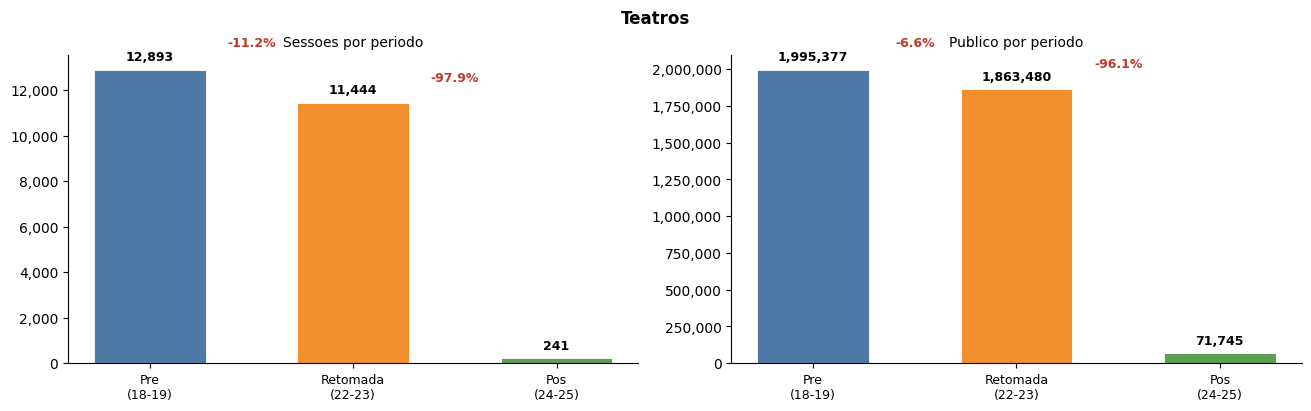

  Linguagens — Teatros


,Linguagem,Sessoes,% ses.,Publico,% pub.
0,Teatro,"8,976","1,427,492",36.5%,36.3%
1,Música,"7,707","1,856,201",31.4%,47.2%
2,Audiovisual,"4,762","200,338",19.4%,5.1%
3,Circo,"1,488","234,408",6.1%,6.0%
4,Dança,"1,264","155,168",5.1%,3.9%
5,Literatura,215,"36,131",0.9%,0.9%
6,(sem classificacao),166,"20,864",0.7%,0.5%


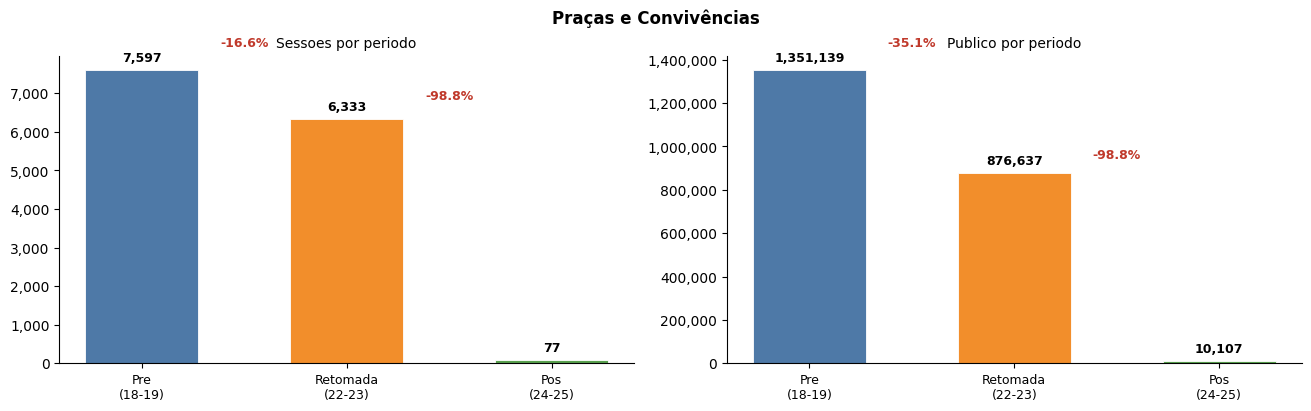

  Linguagens — Praças e Convivências


,Linguagem,Sessoes,% ses.,Publico,% pub.
0,Música,"5,462","1,178,878",39.0%,52.7%
1,Circo,"2,079","362,956",14.8%,16.2%
2,Literatura,"2,053","170,833",14.7%,7.6%
3,Teatro,"1,820","221,863",13.0%,9.9%
4,Dança,"1,568","193,581",11.2%,8.7%
5,Audiovisual,437,"34,468",3.1%,1.5%
6,(sem classificacao),588,"75,304",4.2%,3.4%


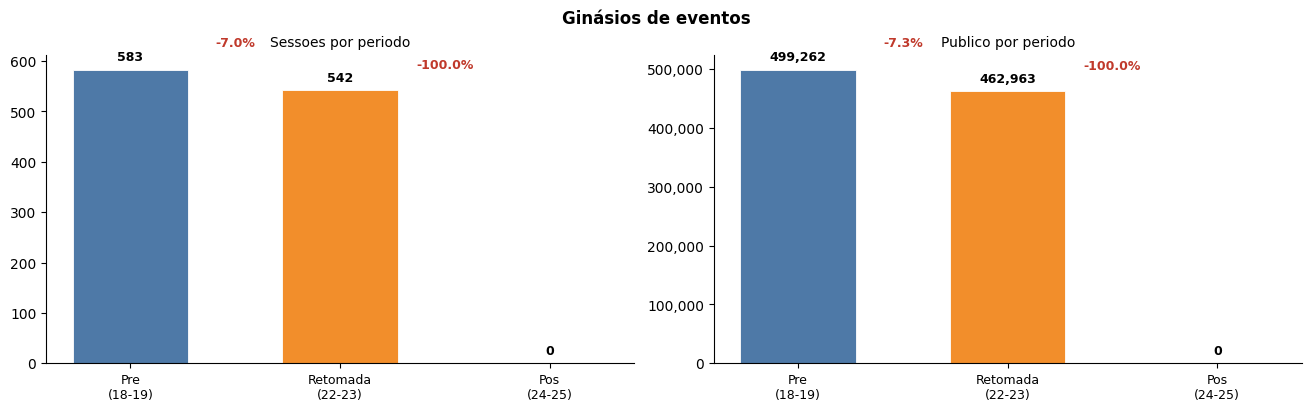

  Linguagens — Ginásios de eventos


,Linguagem,Sessoes,% ses.,Publico,% pub.
0,Música,830,"809,222",73.8%,84.1%
1,Circo,93,"30,329",8.3%,3.2%
2,Teatro,87,"20,269",7.7%,2.1%
3,Dança,49,"21,172",4.4%,2.2%
4,Literatura,34,"54,517",3.0%,5.7%
5,Audiovisual,7,636,0.6%,0.1%
6,(sem classificacao),25,"26,080",2.2%,2.7%


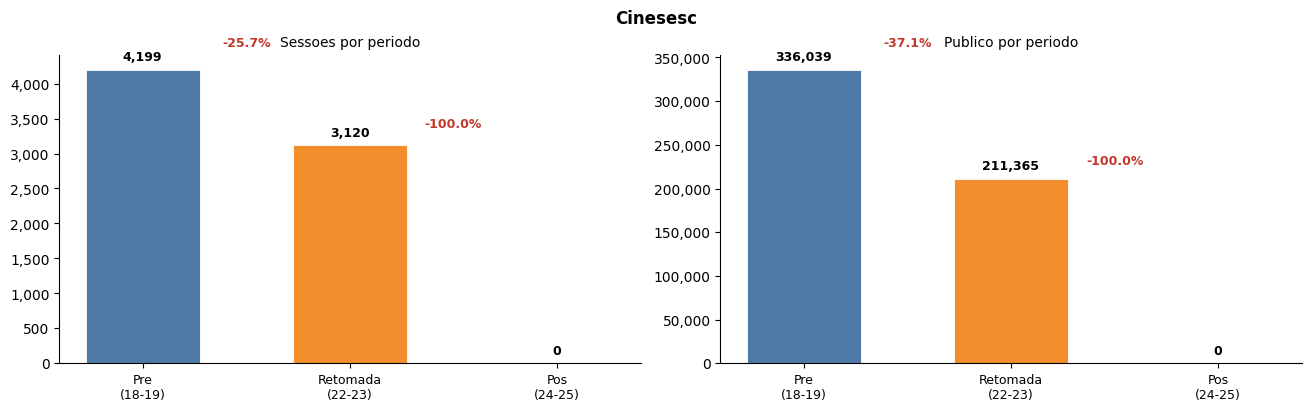

  Linguagens — Cinesesc


,Linguagem,Sessoes,% ses.,Publico,% pub.
0,Audiovisual,"7,315","547,275",99.9%,100.0%
1,(sem classificacao),4,129,0.1%,0.0%


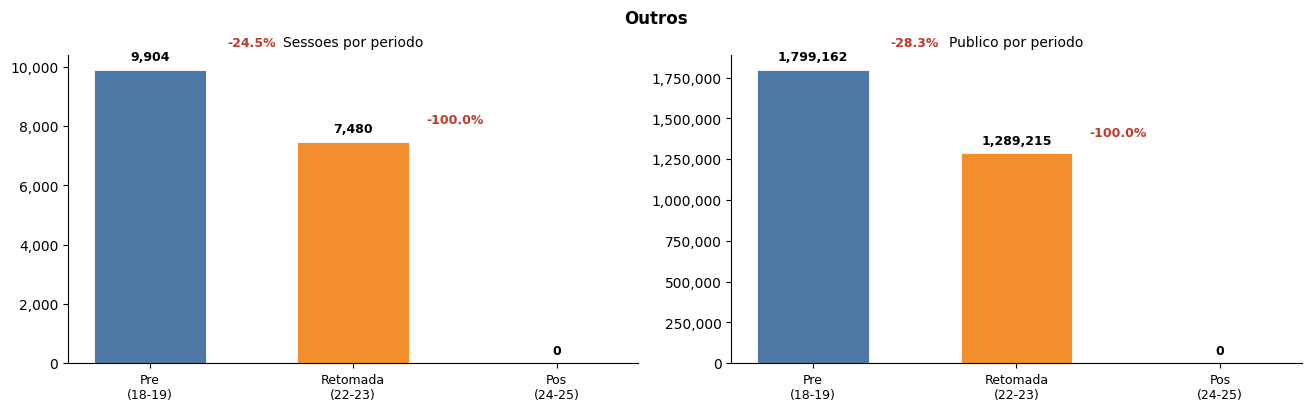

  Linguagens — Outros


,Linguagem,Sessoes,% ses.,Publico,% pub.
0,Música,"7,156","2,031,623",41.2%,65.8%
1,Teatro,"4,727","366,712",27.2%,11.9%
2,Audiovisual,"1,858","78,887",10.7%,2.6%
3,Circo,"1,322","293,602",7.6%,9.5%
4,Literatura,989,"115,261",5.7%,3.7%
5,Dança,921,"129,982",5.3%,4.2%
6,(sem classificacao),411,"72,310",2.4%,2.3%


In [77]:
# Comparacao temporal por periodo e categoria

PERIODO_MAP = {
    2017: 'Pre-pandemia', 2018: 'Pre-pandemia', 2019: 'Pre-pandemia',
    2022: 'Retomada', 2023: 'Retomada', 2024: 'Retomada',
    2025: 'Pos-pandemia', 2026: 'Pos-pandemia',
}
P_ORDEM = ['Pre-pandemia', 'Retomada', 'Pos-pandemia']
P_LABEL = {'Pre-pandemia': 'Pre\n(18-19)', 'Retomada': 'Retomada\n(22-23)', 'Pos-pandemia': 'Pos\n(24-25)'}
P_CORES = {'Pre-pandemia': '#4e79a7', 'Retomada': '#f28e2b', 'Pos-pandemia': '#59a14f'}

_CATS_PROPRIAS = {'Teatros', 'Ginasios de eventos', 'Cinesesc',
                  'Salas de Espetaculo e Comedorias', 'Pracas e Convivencias'}

# usa as categorias reais do _local_meses
_CATS_PROPRIAS_REAL = {
    'Teatros', 'Ginásios de eventos', 'Cinesesc',
    'Salas de Espetáculo e Comédorias', 'Praças e Convivências',
}
def _cat_display(lg):
    return lg if lg in _CATS_PROPRIAS_REAL else 'Outros'

CAT_ORDEM = [
    'Teatros', 'Praças e Convivências', 'Salas de Espetáculo e Comédorias',
    'Ginásios de eventos', 'Cinesesc', 'Outros',
]

# Enriquece df_apresentacoes
_lm_cat = (
    _local_meses[_local_meses['selecao'] == 'recorrente']
    [['uo', 'local_nome', 'local_grupo']].copy()
)
_lm_cat['cat_display'] = _lm_cat['local_grupo'].apply(_cat_display)

_df = df_apresentacoes.merge(_lm_cat, on=['uo', 'local_nome'], how='left')
_df['presentes'] = pd.to_numeric(_df['presentes'], errors='coerce').fillna(0)

_df['_ano'] = pd.to_datetime(_df['datainicio'], errors='coerce').dt.year

_df['periodo'] = _df['_ano'].map(PERIODO_MAP)
_df = _df[_df['periodo'].notna()]

def _pct(a, b):
    if not a or pd.isna(a):
        return None
    return (b - a) / a * 100

def _fmt(v):
    if v is None:
        return 'n/a'
    s = f'+{v:.1f}%' if v >= 0 else f'{v:.1f}%'
    return s

# Loop por categoria
for cat in CAT_ORDEM:
    _sub = _df[_df['cat_display'] == cat]
    if _sub.empty:
        continue

    # Agrega por periodo
    _agg = (
        _sub.groupby('periodo')
        .agg(sessoes=('sessao_id', 'nunique'), presentes=('presentes', 'sum'))
        .reindex(P_ORDEM).fillna(0)
    )
    ses = _agg['sessoes'].values.astype(float)
    pub = _agg['presentes'].values.astype(float)

    # Figura: 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    x = range(len(P_ORDEM))
    cores = [P_CORES[p] for p in P_ORDEM]
    labels = [P_LABEL[p] for p in P_ORDEM]

    # Sessoes
    bars = ax1.bar(x, ses, color=cores, edgecolor='white', linewidth=0.6, width=0.55)
    for bar, v in zip(bars, ses):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ses.max()*0.02,
                 f'{int(v):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for i, dv in enumerate([_pct(ses[0], ses[1]), _pct(ses[1], ses[2])]):
        if dv is not None:
            c = '#27ae60' if dv >= 0 else '#c0392b'
            ax1.text((i + i+1)/2, max(ses[i], ses[i+1])*1.08,
                     _fmt(dv), ha='center', fontsize=9, color=c, fontweight='bold')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(labels, fontsize=9)
    ax1.set_title('Sessoes por periodo', fontsize=10)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax1.spines[['top','right']].set_visible(False)

    # Publico
    bars2 = ax2.bar(x, pub, color=cores, edgecolor='white', linewidth=0.6, width=0.55)
    for bar, v in zip(bars2, pub):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + pub.max()*0.02,
                 f'{int(v):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for i, dv in enumerate([_pct(pub[0], pub[1]), _pct(pub[1], pub[2])]):
        if dv is not None:
            c = '#27ae60' if dv >= 0 else '#c0392b'
            ax2.text((i + i+1)/2, max(pub[i], pub[i+1])*1.08,
                     _fmt(dv), ha='center', fontsize=9, color=c, fontweight='bold')
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(labels, fontsize=9)
    ax2.set_title('Publico por periodo', fontsize=10)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax2.spines[['top','right']].set_visible(False)

    fig.suptitle(cat, fontsize=12, fontweight='bold')
    plt.show()

    # Linguagens
    _tot_ses = _agg['sessoes'].sum()
    _tot_pub = _agg['presentes'].sum()
    _ling = (
        _sub[_sub['linguagem'].notna()]
        .groupby('linguagem')
        .agg(sessoes=('sessao_id', 'nunique'), presentes=('presentes', 'sum'))
        .sort_values('sessoes', ascending=False)
        .reset_index()
    )
    if not _ling.empty:
        _ling['pct_ses'] = (_ling['sessoes']  / _tot_ses * 100).round(1).astype(str) + '%'
        _ling['pct_pub'] = (_ling['presentes'] / _tot_pub * 100).round(1).astype(str) + '%'
        _ling['sessoes']   = _ling['sessoes'].apply(lambda v: f'{int(v):,}')
        _ling['presentes'] = _ling['presentes'].apply(lambda v: f'{int(v):,}')
        _sem_ses = _sub[_sub['linguagem'].isna()]['sessao_id'].nunique()
        _sem_pub = _sub[_sub['linguagem'].isna()]['presentes'].sum()
        if _sem_ses > 0:
            _extra = pd.DataFrame([{
                'linguagem': '(sem classificacao)',
                'sessoes': f'{int(_sem_ses):,}',
                'pct_ses': f'{_sem_ses/_tot_ses*100:.1f}%',
                'presentes': f'{int(_sem_pub):,}',
                'pct_pub': f'{_sem_pub/_tot_pub*100:.1f}%',
            }])
            _ling = pd.concat([_ling, _extra], ignore_index=True)
        _ling.columns = ['Linguagem', 'Sessoes', '% ses.', 'Publico', '% pub.']
        print(f'  Linguagens — {cat}')
        display(_ling)
    else:
        print(f'  {cat}: nenhuma linguagem classificada')
    print()


In [78]:
# ── Diagnóstico: % pago / gratuito por período e linguagem ──────────────────────────────
# Usa PERIODOS já definido; exclui 'RPS' (2025-2026).
# acesso derivado de precificacao_desc (classificação apenas aqui, antes de adicionar ao base).

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Base: usa PERIODOS existente, sem redefinir ────────────────────────────────────────────
_df = df_apresentacoes.copy()
_df['presentes'] = pd.to_numeric(_df['presentes'], errors='coerce').fillna(0)
_df['_ano'] = pd.to_datetime(_df['datainicio'], errors='coerce').dt.year
_df['periodo'] = _df['_ano'].map(PERIODOS)
_df = _df[_df['periodo'].isin(['Pré-pandemia', 'Pós-pandemia'])].copy()  # exclui RPS

# ── Classifica acesso ───────────────────────────────────────────────────────────────────────────────
def _acesso(p):
    if pd.isna(p): return 'Não informado'
    p = str(p).lower().strip()
    if 'gratuit' in p or 'suger' in p: return 'Gratuito'
    return 'Pago'

_df['acesso'] = _df['precificacao_desc'].apply(_acesso)

P2_ORDEM = ['Pré-pandemia', 'Pós-pandemia']

# ── 1. Distribuição raw de precificacao_desc ────────────────────────────────────────────────
print('=== Valores raw de precificacao_desc ===')
_raw = (
    _df.groupby(['precificacao_desc', 'acesso', 'periodo'], dropna=False)['sessao_id']
    .nunique().rename('sessoes').reset_index()
    .sort_values(['periodo', 'sessoes'], ascending=[True, False])
)
display(_raw)

# ── 2. % pago / gratuito total por período (sessões e público) ──────────────────────────
print('\n=== % Acesso total por período ===')
_tot = (
    _df.groupby(['periodo', 'acesso'])
    .agg(sessoes=('sessao_id', 'nunique'), presentes=('presentes', 'sum'))
    .reset_index()
)
_tot_p = _tot.pivot_table(index='acesso', columns='periodo',
                           values=['sessoes', 'presentes'], fill_value=0)
# adiciona % dentro de cada período
_pct_ses = _tot_p['sessoes'].div(_tot_p['sessoes'].sum()).mul(100).round(1)
_pct_pub = _tot_p['presentes'].div(_tot_p['presentes'].sum()).mul(100).round(1)
_pct_ses.columns = [f'% sessões {c}' for c in _pct_ses.columns]
_pct_pub.columns = [f'% público {c}' for c in _pct_pub.columns]
_tot_p.columns   = [f'{m} {c}' for m, c in _tot_p.columns]
_tab_tot = pd.concat([_tot_p, _pct_ses, _pct_pub], axis=1)
# reordena colunas: pré | pós
_col_order = []
for p in P2_ORDEM:
    for m in ['sessoes', '% sessões', 'presentes', '% público']:
        c = f'{m} {p}'
        if c in _tab_tot.columns: _col_order.append(c)
display(_tab_tot[_col_order])

# ── 3. % pago / gratuito por linguagem em cada período ───────────────────────────────
print('\n=== % Acesso por linguagem e período (sessões) ===')
_ling_ac = (
    _df[_df['linguagem'].notna()]
    .groupby(['linguagem', 'acesso', 'periodo'])
    .agg(sessoes=('sessao_id', 'nunique'), presentes=('presentes', 'sum'))
    .reset_index()
)
for per in P2_ORDEM:
    _sub = _ling_ac[_ling_ac['periodo'] == per].copy()
    if _sub.empty: continue
    _piv = _sub.pivot_table(index='linguagem', columns='acesso',
                             values=['sessoes', 'presentes'], fill_value=0)
    # % por linha
    _tot_ses = _piv['sessoes'].sum(axis=1)
    _tot_pub = _piv['presentes'].sum(axis=1)
    for ac in _piv['sessoes'].columns:
        _piv[('% sessões', ac)] = (_piv[('sessoes', ac)] / _tot_ses * 100).round(1)
        _piv[('% público', ac)] = (_piv[('presentes', ac)] / _tot_pub * 100).round(1)
    _piv = _piv.sort_values(('sessoes', 'Pago'), ascending=False
                             ) if 'Pago' in _piv['sessoes'].columns else _piv
    print(f'  {per}')
    display(_piv)
    print()


=== Valores raw de precificacao_desc ===


,precificacao_desc,acesso,periodo,sessoes
0,Aberto ao público,Pago,Pré-pandemia,4943
192,Ingresso - R$ 20.00 / R$ 10.00 / R$ 6.00,Pago,Pré-pandemia,4633
127,Aberto ao público - Sem retirada de ingressos.,Pago,Pré-pandemia,4392
236,Ingresso - R$ 30.00 / R$ 15.00 / R$ 9.00,Pago,Pré-pandemia,2556
299,NaN,Não informado,Pré-pandemia,2493
...,...,...,...,...
252,Ingresso - R$ 40.00 / R$ 20.00 / R$ 13.00,Pago,Pós-pandemia,1
261,Ingresso - R$ 50.00 / R$ 25.00 / R$ 25.00,Pago,Pós-pandemia,1
283,Inscrição - R$ 24.00 / R$ 12.00 / R$ 12.00,Pago,Pós-pandemia,1
287,Inscrição - R$ 30.00 / R$ 15.00 / R$ 10.00,Pago,Pós-pandemia,1



=== % Acesso total por período ===


,sessoes Pré-pandemia,% sessões Pré-pandemia,presentes Pré-pandemia,% público Pré-pandemia,sessoes Pós-pandemia,% sessões Pós-pandemia,presentes Pós-pandemia,% público Pós-pandemia
acesso,,,,,,,,
Gratuito,34.0,0.1,2321.0,0.0,21.0,0.1,507.0,0.0
Não informado,2493.0,7.1,426515.0,7.1,2794.0,9.7,516132.0,11.0
Pago,32649.0,92.8,5552143.0,92.8,26104.0,90.3,4187021.0,89.0



=== % Acesso por linguagem e período (sessões) ===
  Pré-pandemia


presentes                           sessoes                \
acesso       Gratuito Não informado       Pago Gratuito Não informado   
linguagem                                                               
Música          618.0      188333.0  3111660.0     10.0         651.0   
Audiovisual      44.0       31956.0   514603.0      3.0         598.0   
Teatro          850.0       49209.0   993979.0      7.0         380.0   
Circo             0.0       82528.0   417140.0      0.0         340.0   
Dança           800.0       36479.0   227994.0     11.0         261.0   
Literatura        0.0       21793.0   214684.0      0.0         161.0   

                     % sessões % público     % sessões     % público  \
acesso          Pago  Gratuito  Gratuito Não informado Não informado   
linguagem                                                              
Música       10723.0       0.1       0.0           5.7           5.7   
Audiovisual   7940.0       0.0       0.0           7.0           5.8   
Teatro        7699.0       0.1       0.1           4.7           4.7   
Circo         2284.0       0.0       0.0          13.0          16.5   
Dança         1932.0       0.5       0.3          11.8          13.8   
Literatura    1623.0       0.0       0.0           9.0           9.2   

            % sessões % público  
acesso           Pago      Pago  
linguagem                        
Música           94.2      94.3  
Audiovisual      93.0      94.1  
Teatro           95.2      95.2  
Circo            87.0      83.5  
Dança            87.7      85.9  
Literatura       91.0      90.8


  Pós-pandemia


presentes                           sessoes                        \
acesso       Gratuito Não informado       Pago Gratuito Não informado    Pago   
linguagem                                                                       
Música           90.0      244156.0  2291255.0      2.0        1124.0  8510.0   
Teatro            0.0       67361.0   889319.0      0.0         527.0  6861.0   
Audiovisual     367.0        9448.0   304487.0     18.0         216.0  5601.0   
Circo             0.0      110971.0   306501.0      0.0         390.0  1940.0   
Dança             0.0       36350.0   197528.0      0.0         160.0  1430.0   
Literatura        0.0       20819.0   118930.0      0.0         207.0  1293.0   

            % sessões % público     % sessões     % público % sessões  \
acesso       Gratuito  Gratuito Não informado Não informado      Pago   
linguagem                                                               
Música            0.0       0.0          11.7           9.6      88.3   
Teatro            0.0       0.0           7.1           7.0      92.9   
Audiovisual       0.3       0.1           3.7           3.0      96.0   
Circo             0.0       0.0          16.7          26.6      83.3   
Dança             0.0       0.0          10.1          15.5      89.9   
Literatura        0.0       0.0          13.8          14.9      86.2   

            % público  
acesso           Pago  
linguagem              
Música           90.4  
Teatro           93.0  
Audiovisual      96.9  
Circo            73.4  
Dança            84.5  
Literatura       85.1

## Diagnóstico: qualidade do campo `lugares` nos 100 espaços recorrentes

`lugares` é preenchido no nível da **ação** (`atividade_id`) — o mesmo valor
aparece em todas as sessões daquela ação. O erro de cadastro mais comum é
informar a **capacidade total da ação** (lugar × nº de sessões) em vez da
**capacidade por sessão**.

**Critério adotado:** para cada ação, calcula-se a capacidade total ofertada
(`lugares × n_sessões`) e compara-se com o total de presentes (`∑ presentes`
de todas as sessões). Se a capacidade ofertada for ≥ ao público registrado, o
dado é considerado **correto**; caso contrário, há inconsistência.

Classificação por ação:

| Categoria | Condição |
|---|---|
| **Correto** | `lugares > 0` e `lugares × n_sessões ≥ ∑ presentes` |
| **Sem informação** | `lugares` ausente ou zero |
| **Incorreto** | `lugares > 0` mas `lugares × n_sessões < ∑ presentes` |

O diagnóstico é exibido por grupo de espaço (mesmas 6 categorias do gráfico anterior)
e detalhado por espaço para as ações com problema.


In [62]:
# ── Diagnóstico de qualidade do campo 'lugares' — 100 espaços recorrentes ─────

_CATS_PROPRIAS = {
    'Teatros', 'Ginásios de eventos', 'Cinesesc',
    'Salas de Espetáculo e Comedorias', 'Praças e Convivências',
}
def _cat_display(lg):
    return lg if lg in _CATS_PROPRIAS else 'Outros'

_CAT_ORDEM = [
    'Teatros', 'Praças e Convivências', 'Salas de Espetáculo e Comedorias',
    'Ginásios de eventos', 'Cinesesc', 'Outros',
]

# Enriquece df_apresentacoes (já filtrado para 100 recorrentes) com categoria
_lm_cat = (
    _local_meses[_local_meses['selecao'] == 'recorrente']
    [['uo', 'local_nome', 'local_grupo', 'unidade']]
    .copy()
)
_lm_cat['cat_display'] = _lm_cat['local_grupo'].apply(_cat_display)

_base = df_apresentacoes.merge(_lm_cat, on=['uo', 'local_nome'], how='left')
_base['presentes'] = pd.to_numeric(_base['presentes'], errors='coerce').fillna(0)
_base['lugares']   = pd.to_numeric(_base['lugares'],   errors='coerce')

# Agrega por ação: lugares é constante por atividade_id
_por_acao = (
    _base.groupby(['atividade_id', 'cat_display', 'uo', 'local_nome'])
    .agg(
        n_sessoes       = ('sessao_id',  'nunique'),
        lugares         = ('lugares',    'first'),
        presentes_total = ('presentes',  'sum'),
    )
    .reset_index()
)
_por_acao['lugares'] = pd.to_numeric(_por_acao['lugares'], errors='coerce')

def _diag_lugares(row):
    if pd.isna(row['lugares']) or row['lugares'] <= 0:
        return 'sem_informacao'
    if row['lugares'] * row['n_sessoes'] >= row['presentes_total']:
        return 'correto'
    return 'incorreto'

_por_acao['diag'] = _por_acao.apply(_diag_lugares, axis=1)

# ── Resumo por categoria ──────────────────────────────────────────────────────
_res = (
    _por_acao.groupby(['cat_display', 'diag'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['correto', 'sem_informacao', 'incorreto'], fill_value=0)
)
for col in ['correto', 'sem_informacao', 'incorreto']:
    if col not in _res.columns:
        _res[col] = 0
_res['total'] = _res.sum(axis=1)
_res['%_correto']   = (_res['correto']       / _res['total'] * 100).round(1)
_res['%_sem_info']  = (_res['sem_informacao'] / _res['total'] * 100).round(1)
_res['%_incorreto'] = (_res['incorreto']      / _res['total'] * 100).round(1)
_res = _res.reindex([c for c in _CAT_ORDEM if c in _res.index])

print("Qualidade do campo 'lugares' — critério: lugares × n_sessões ≥ ∑ presentes")
print()
HDR = f"  {'Categoria':<34} {'Ações':>7}  {'Correto':>8} {'%':>6}  {'Sem info':>8} {'%':>6}  {'Incorreto':>9} {'%':>6}"
SEP = "  " + "─" * (len(HDR) - 2)
print(HDR)
print(SEP)
for cat, row in _res.iterrows():
    print(
        f"  {cat:<34} {int(row['total']):>7,}  "
        f"{int(row['correto']):>8,} {row['%_correto']:>5.1f}%  "
        f"{int(row['sem_informacao']):>8,} {row['%_sem_info']:>5.1f}%  "
        f"{int(row['incorreto']):>9,} {row['%_incorreto']:>5.1f}%"
    )
_tot = _res[['correto', 'sem_informacao', 'incorreto', 'total']].sum()
print(SEP)
print(
    f"  {'TOTAL':<34} {int(_tot['total']):>7,}  "
    f"{int(_tot['correto']):>8,} {_tot['correto']/_tot['total']*100:>5.1f}%  "
    f"{int(_tot['sem_informacao']):>8,} {_tot['sem_informacao']/_tot['total']*100:>5.1f}%  "
    f"{int(_tot['incorreto']):>9,} {_tot['incorreto']/_tot['total']*100:>5.1f}%"
)

# ── Detalhe por espaço: ações não-corretas ────────────────────────────────────
print("\n" + "═" * 80)
print("  DETALHE POR ESPAÇO — ações com 'sem_informacao' ou 'incorreto'")
print("═" * 80)

for cat in _CAT_ORDEM:
    _prob = _por_acao[
        (_por_acao['cat_display'] == cat) &
        (_por_acao['diag'] != 'correto')
    ]
    if _prob.empty:
        continue

    _espaco_prob = (
        _prob.groupby(['unidade' if 'unidade' in _prob.columns else 'uo', 'local_nome', 'diag'])
        .agg(acoes=('atividade_id', 'count'), presentes=('presentes_total', 'sum'))
        .reset_index()
        .sort_values(['diag', 'presentes'], ascending=[True, False])
    )
    # fallback: usa 'uo' se 'unidade' não estiver disponível
    if 'unidade' not in _prob.columns:
        _espaco_prob = (
            _prob.groupby(['uo', 'local_nome', 'diag'])
            .agg(acoes=('atividade_id', 'count'), presentes=('presentes_total', 'sum'))
            .reset_index()
            .sort_values(['diag', 'presentes'], ascending=[True, False])
        )

    _n_esp = _espaco_prob[['uo', 'local_nome']].drop_duplicates().__len__() if 'uo' in _espaco_prob.columns else len(_espaco_prob)
    print(f"\n▌ {cat}  ({_n_esp} espaços com problema)")
    display(_espaco_prob.reset_index(drop=True))

# ── Espaços 100% corretos por categoria ───────────────────────────────────────
print("\n" + "═" * 80)
print("  ESPAÇOS COM LUGARES 100% CORRETO em todas as ações")
print("═" * 80)
_ok_total = (
    _por_acao.groupby(['cat_display', 'uo', 'local_nome'])['diag']
    .apply(lambda x: (x == 'correto').all())
    .reset_index(name='todos_corretos')
)
for cat in _CAT_ORDEM:
    _cat_ok = _ok_total[(_ok_total['cat_display'] == cat) & _ok_total['todos_corretos']]
    _cat_tot = _ok_total[_ok_total['cat_display'] == cat]
    print(f"  {cat:<34} {len(_cat_ok):>3} / {len(_cat_tot)} espaços com lugares 100% correto")


Qualidade do campo 'lugares' — critério: lugares × n_sessões ≥ ∑ presentes

  Categoria                            Ações   Correto      %  Sem info      %  Incorreto      %
  ──────────────────────────────────────────────────────────────────────────────────────────────
  Teatros                             16,254    15,313  94.2%       384   2.4%        557   3.4%
  Praças e Convivências               11,554     7,441  64.4%     1,626  14.1%      2,487  21.5%
  Salas de Espetáculo e Comedorias     5,734     3,651  63.7%     1,141  19.9%        942  16.4%
  Ginásios de eventos                  1,108       719  64.9%       132  11.9%        257  23.2%
  Cinesesc                             3,789     3,687  97.3%         0   0.0%        102   2.7%
  Outros                               5,268     4,293  81.5%       226   4.3%        749  14.2%
  ──────────────────────────────────────────────────────────────────────────────────────────────
  TOTAL                               43,707    35,

,uo,local_nome,diag,acoes,presentes
0,58,Teatro Paulo Autran,incorreto,26,107120.0
1,62,TEATRO ANCHIETA,incorreto,37,67115.0
2,63,Teatro,incorreto,42,41682.0
3,73,Teatro,incorreto,12,37471.0
4,78,TEATRO,incorreto,65,25708.0
5,88,Teatro,incorreto,20,19576.0
6,93,Teatro,incorreto,39,16828.0
7,49,Teatro - 2º andar,incorreto,7,16010.0
8,70,TEATRO,incorreto,13,10820.0
9,84,Teatro,incorreto,35,10759.0



▌ Praças e Convivências  (29 espaços com problema)


,uo,local_nome,diag,acoes,presentes
0,58,Praça,incorreto,166,76750.0
1,81,Circo,incorreto,170,71345.0
2,91,Tenda de Convivência,incorreto,151,69200.0
3,87,Área de Convivência,incorreto,207,66867.0
4,66,PRAÇA DE EVENTOS,incorreto,152,58585.0
5,73,Praça de Convivência,incorreto,83,53366.0
6,93,Area Convivência,incorreto,100,39921.0
7,70,PÇA COBERTA,incorreto,146,36765.0
8,88,Área de Convivência,incorreto,89,34704.0
9,94,PRAÇA DE CONVIVÊNCIA,incorreto,96,33287.0



▌ Salas de Espetáculo e Comedorias  (14 espaços com problema)


...


▌ Cinesesc  (1 espaços com problema)


,uo,local_nome,diag,acoes,presentes
0,59,Sala de exibição,incorreto,102,32428.0



▌ Outros  (17 espaços com problema)


,uo,local_nome,diag,acoes,presentes
0,56,PALCO DA PRAÇA DE EVENTOS,incorreto,107,77052.0
1,72,Tenda,incorreto,171,62143.0
2,55,PRAÇA PAU BRASIL,incorreto,41,47491.0
3,88,Quadras,incorreto,17,46247.0
4,56,PRAÇA DE EVENTOS,incorreto,136,45773.0
5,53,BIBLIOSESC,incorreto,40,35826.0
6,63,Deck Solariun,incorreto,22,33077.0
7,75,Espaço Multiuso,incorreto,59,26993.0
8,55,UNIDADE,incorreto,1,26019.0
9,57,QUINTAL,incorreto,38,22403.0



════════════════════════════════════════════════════════════════════════════════
  ESPAÇOS COM LUGARES 100% CORRETO em todas as ações
════════════════════════════════════════════════════════════════════════════════
  Teatros                              0 / 25 espaços com lugares 100% correto
  Praças e Convivências                1 / 30 espaços com lugares 100% correto
  Salas de Espetáculo e Comedorias     0 / 14 espaços com lugares 100% correto
  Ginásios de eventos                  0 / 13 espaços com lugares 100% correto
  Cinesesc                             0 / 1 espaços com lugares 100% correto
  Outros                               0 / 17 espaços com lugares 100% correto


In [ ]:
output_file = OUTPUT_PATH / "apresentacoes_longitudinal.xlsx"
df_raw_acoes_preview.to_excel(output_file, index=False)
print(f"Exportado {len(df_raw_acoes_preview)} linhas para {output_file}")